# 04 — somite subclustering

**Feeds:** ED Fig 7a

**Position in the chain:** run the numbered stages in order

Ported from the original analysis. Saved cell outputs are from the original run, and paths in them appear as `<analysis-root>/...`.

**Changes from the original notebook**, so that it runs from this repository:
1. Paths. The first code cell finds the repository from any working directory inside it; the original looked for `src/` at most two levels up. `PROJECT_ROOT`, which was the analysis directory, is now `scrnaseq/chain_inputs/`, the shipped files that no notebook writes, in the same layout. `DEV_ROOT`, under which the notebook writes, is `$SCRNASEQ_RESULTS_ROOT/trunk_main_dev/` (default `scrnaseq/output/trunk_main_dev/`) instead of the analysis directory's `trunk_main_dev/`.
2. The SMD z-score files are read from `scrnaseq/chain_inputs/trunk_main_dev/results/smd_runs/` (`PROJECT_ROOT / "trunk_main_dev" / "results"`) instead of `RESULTS_DIR`, where they sat in the original analysis directory.
3. Removed the `.to_clipboard()` call, which copied a table to the system clipboard for pasting into the Supplementary Data spreadsheet and fail on a machine without a clipboard. The expression before each call is unchanged.
4. The somite subcluster labels come from one `sc.tl.leiden` call on the selected-gene graph (resolution 0.75, seed 3, `flavor="igraph"`, `n_iterations=-1`, as `03` calls it), with the cluster-id to name map written into the cell. The original read the same run's labels and names from files saved by a separate clustering-stability analysis that is not part of this repository. `sc.tl.leiden` writes the raw cluster ids to `obs["leiden_morph_somite_raw"]`. Clusters 1 and 6 are both named Caudal Somite, as in the original. The `meta.json` strings naming the label source are unchanged.

No other line of code was changed.


# 04 - Somite Subclustering

Depends on: 01_preprocessing, 02_trunk_main artifacts.

In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "trunk_morph_ref").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root containing src/trunk_morph_ref/")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.trunk_morph_ref.paths import chain_inputs_root

# Inputs that no notebook writes: scrnaseq/chain_inputs/, laid out as the original analysis directory.
PROJECT_ROOT = chain_inputs_root(REPO_ROOT)

import os
os.chdir(REPO_ROOT)


## Setup and Imports


In [ ]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [ ]:
import pickle
import random

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from cmcrameri.cm import batlow
from scipy.sparse import coo_matrix, csr_matrix, load_npz, save_npz

/opt/anaconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-pa

In [ ]:
plt.rcParams["svg.fonttype"] = "none"  # Keep fonts editable in Illustrator

In [ ]:
from src.trunk_morph_ref.cell_ordering import ordered_cells_by_cluster_clustermap
from src.trunk_morph_ref.paths import init_output_paths, scrnaseq_results_root

# Outputs: $SCRNASEQ_RESULTS_ROOT (default scrnaseq/output/), under trunk_main_dev/ as in the original.
DEV_ROOT = scrnaseq_results_root(REPO_ROOT) / "trunk_main_dev"
RESULTS_DIR, MANUSCRIPT_FIG_DIR, EXTENDED_FIG_DIR = init_output_paths(DEV_ROOT)
from src.trunk_morph_ref.aggregation import (
    cluster_averages_sparse_safe,
)
from src.trunk_morph_ref.correlation import (
    gene_corrcoef_sparse_safe,
)
from src.trunk_morph_ref.plotting import (
    bold_selected_heatmap_yticklabels,
    hide_heatmap_axes_and_colorbar,
    keep_only_selected_heatmap_yticklabels,
    plot_empty_heatmap_axes,
)
from src.trunk_morph_ref.preprocessing import (
    assert_gene_id_index,
    build_legacy_smd_score_table,
    contains_symbol,
    ensure_gene_id_index,
    filter_genes_sparse_safe as filter_genes,
    install_scanpy_symbol_defaults,
    map_legacy_smd_scores_to_adata,
    normalize_unit_variance_sparse_safe as normalize_unit_variance,
    resolve_symbol_dict,
    resolve_symbols,
    symbols_missing,
    symbols_present,
    var_names_to_symbols,
)

# Use gene symbols for plot labels while keeping `var_names` as stable gene IDs.
install_scanpy_symbol_defaults(sc)

In [ ]:
from src.trunk_morph_ref.pipeline_io import (
    load_h5ad,
    load_npy,
    load_pickle,
    save_h5ad,
    save_json,
    save_npy,
    save_pickle,
    stage_dir,
)

In [ ]:
pre_path = stage_dir(RESULTS_DIR, "01_preprocessing")
trunk_path = stage_dir(RESULTS_DIR, "02_trunk_main")
adata_morph_raw = load_h5ad(pre_path / "adata_morph_raw.h5ad")
adata_morph_with_clusters = load_h5ad(trunk_path / "adata_morph_with_clusters.h5ad")
for _adata in [
    adata_morph_raw,
    adata_morph_with_clusters,
]:
    ensure_gene_id_index(_adata)
    assert_gene_id_index(_adata)

print("Loaded 01_preprocessing and 02_trunk_main intermediates")

Loaded 01_preprocessing and 02_trunk_main intermediates


## Somite Subclustering Analysis
Subclustering resolves Anterior Presomitic Mesoderm / Early Somite, Newly Formed Somite, Rostral Somite, Dorsal Somite, Ventral Somite, and Caudal Somite.
This analysis block also generates:
- `Supp. Data 1 - SMD Somite Z-scores`
- `Supp. Data 1 - Top 100 DEGs and scores per Somite subcluster`
- `ED Fig. 7a - Somite subcluster visualizations: UMAP and stacked bar graph`
- `ED Fig. 7a - Somite key gene expression heatmap`


### Somite Provenance Note

This notebook loads the following staged inputs from inside `trunk_main_dev`:

- `<analysis-root>/trunk_main_dev/results/intermediates/01_preprocessing/adata_morph_raw.h5ad`
- `<analysis-root>/trunk_main_dev/results/intermediates/02_trunk_main/adata_morph_with_clusters.h5ad`

It also currently loads legacy-compatible Somite SMD inputs from outside `trunk_main_dev`:

- `<analysis-root>/legacy/results/intermediates/02_trunk_main/adata_morph_with_clusters.h5ad`
- `<analysis-root>/z_morph_somite4.03_001.npy`

So notebook `04` does **not** rerun Somite SMD yet. Instead, it rebuilds the Somite subset from the staged current dev raw/coarse-cluster objects, maps the canonical Somite z-scores onto the current filtered gene space, and then reruns Somite subclustering in that fixed gene space.

Dropping 44 cells not present in adata_morph_with_clusters before coarse-cluster subsetting.
8620 genes after filtering


/opt/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:406: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


939 cells after pre-processing
7918 genes after preprocessing
Recommended n_sub ≈ 751.2
22229 genes after filtering


<analysis-root>/src/trunk_morph_ref/preprocessing.py:190: RuntimeWarning: invalid value encountered in log1p
  score_table[f"log1p_{score_col}"] = np.log1p(score_table[score_col].to_numpy())
<analysis-root>/src/trunk_morph_ref/preprocessing.py:238: RuntimeWarning: invalid value encountered in log1p
  adata_mapped.var[f"log1p_{score_col}"] = np.log1p(


Mapped legacy morph_somite z-scores to current filtered genes: 7880 matched, 38 missing in current data, 51 legacy-only genes ignored.

256 morph_somite genes with z_score >= cutoff


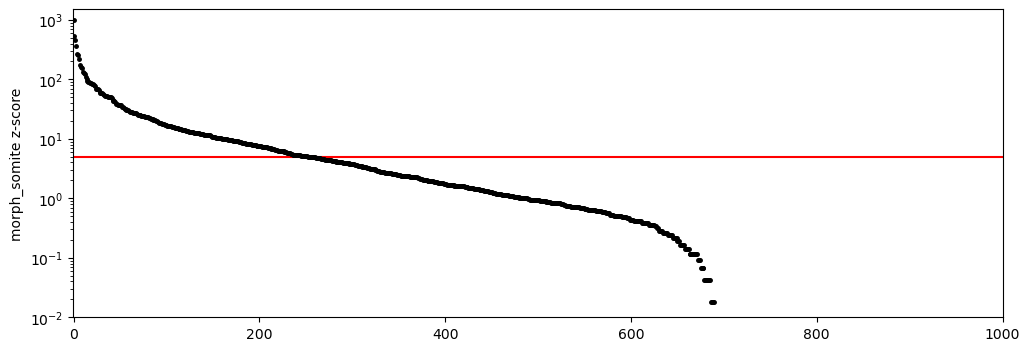

231 genes selected with top morph_somite SMD z-scores
ENSG00000188976
ENSG00000242485
ENSG00000116649
ENSG00000189337
ENSG00000117122
ENSG00000077549
ENSG00000117318
ENSG00000188529
ENSG00000130770
ENSG00000242125
ENSG00000126067
ENSG00000186409
ENSG00000142945
ENSG00000070759
ENSG00000152763
ENSG00000117114
ENSG00000122482
ENSG00000265241
ENSG00000143376
ENSG00000163191
ENSG00000143207
ENSG00000117020
ENSG00000228474
ENSG00000152518
ENSG00000115464
ENSG00000143995
ENSG00000169564
ENSG00000143977
ENSG00000144036
ENSG00000155368
ENSG00000074047
ENSG00000136732
ENSG00000121988
ENSG00000182263
ENSG00000172292
ENSG00000128652
ENSG00000237877
ENSG00000162944
ENSG00000163249
ENSG00000163466
ENSG00000135916
ENSG00000170142
ENSG00000114902
ENSG00000185008
ENSG00000184220
ENSG00000138468
ENSG00000114423
ENSG00000072858
ENSG00000169760
ENSG00000109265
ENSG00000109339
ENSG00000109323
ENSG00000145348
ENSG00000269893
ENSG00000164109
ENSG00000134363
ENSG00000130449
ENSG00000049192
ENSG00000251493
EN

/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


0.72
[]
21


/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_68202/4009281101.py:588: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_morph_somite_SMD_.var["fcluster"] = scipy.cluster.hierarchy.fcluster(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/get/_aggregated.py:138: RuntimeWarning: divide by zero encountered in divide
  var_ *= (group_counts / (group_counts - dof))[:, np.newaxis]
/opt/anaconda3/lib/python3.12/site-packages/scanpy/get/_aggregated.py:138: RuntimeWarning: invalid value encountered in multiply
  var_ *= (group_counts / (group_counts - dof))[:, np.newaxis]
/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


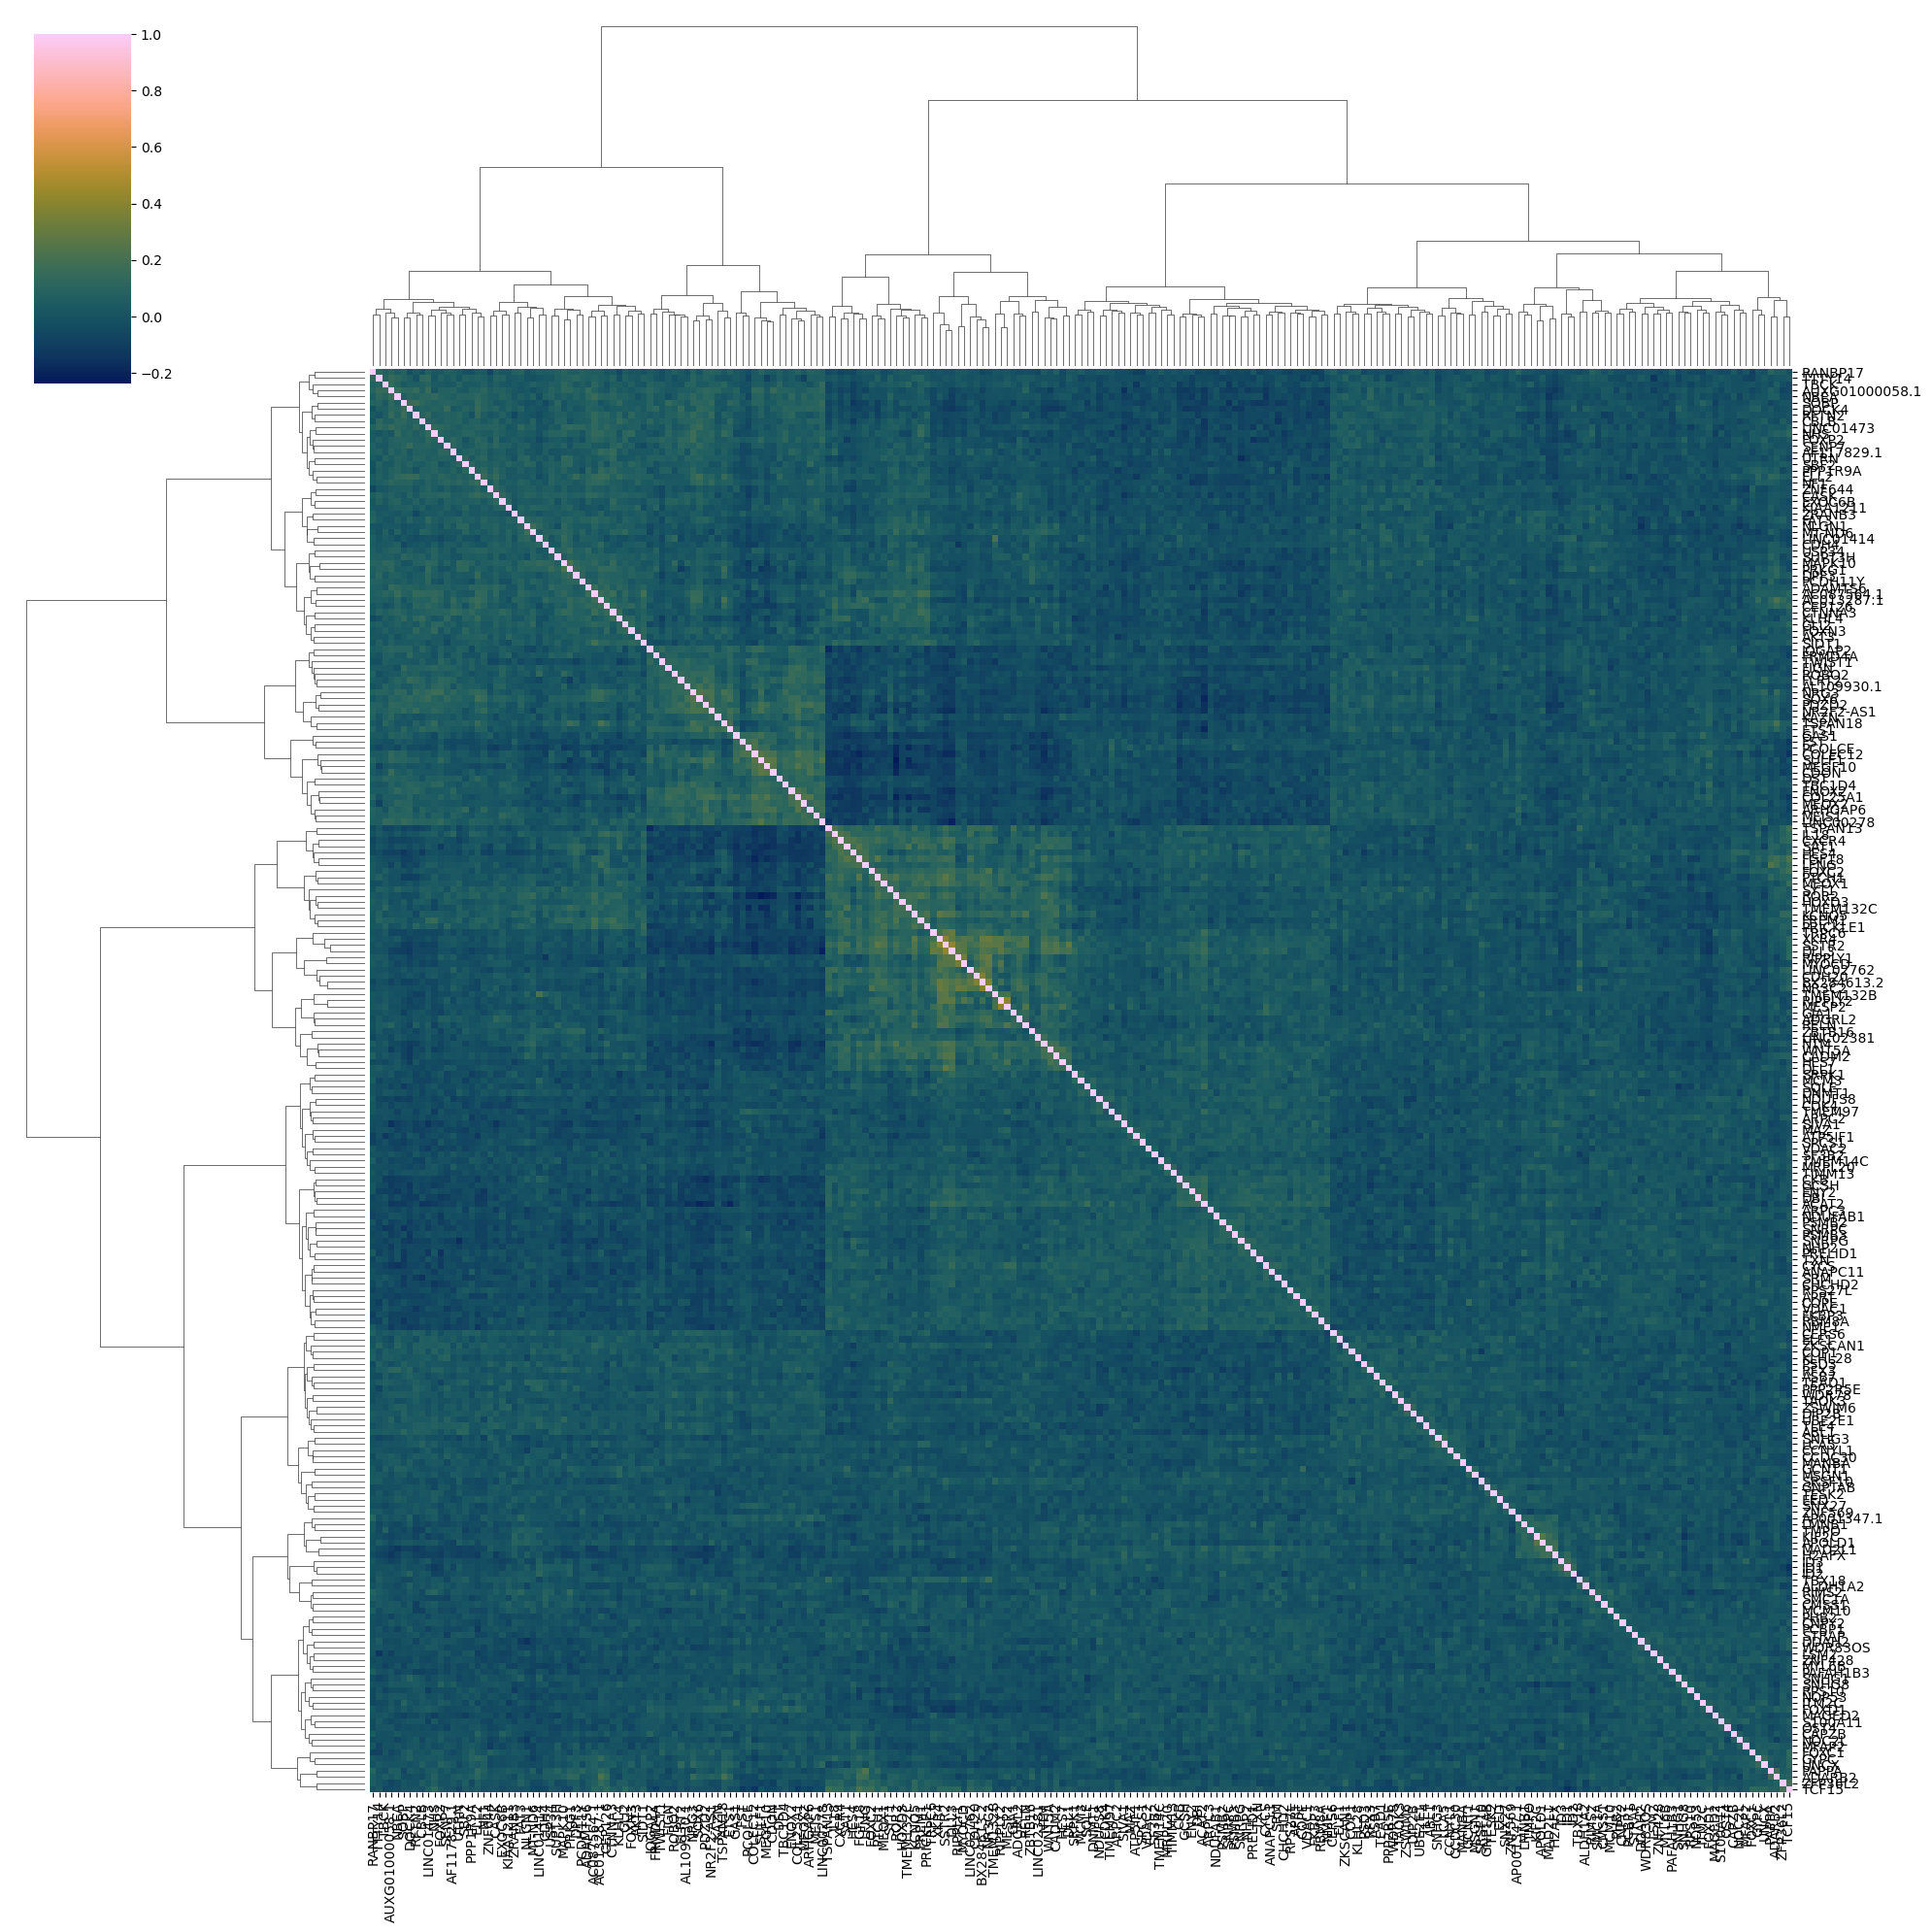

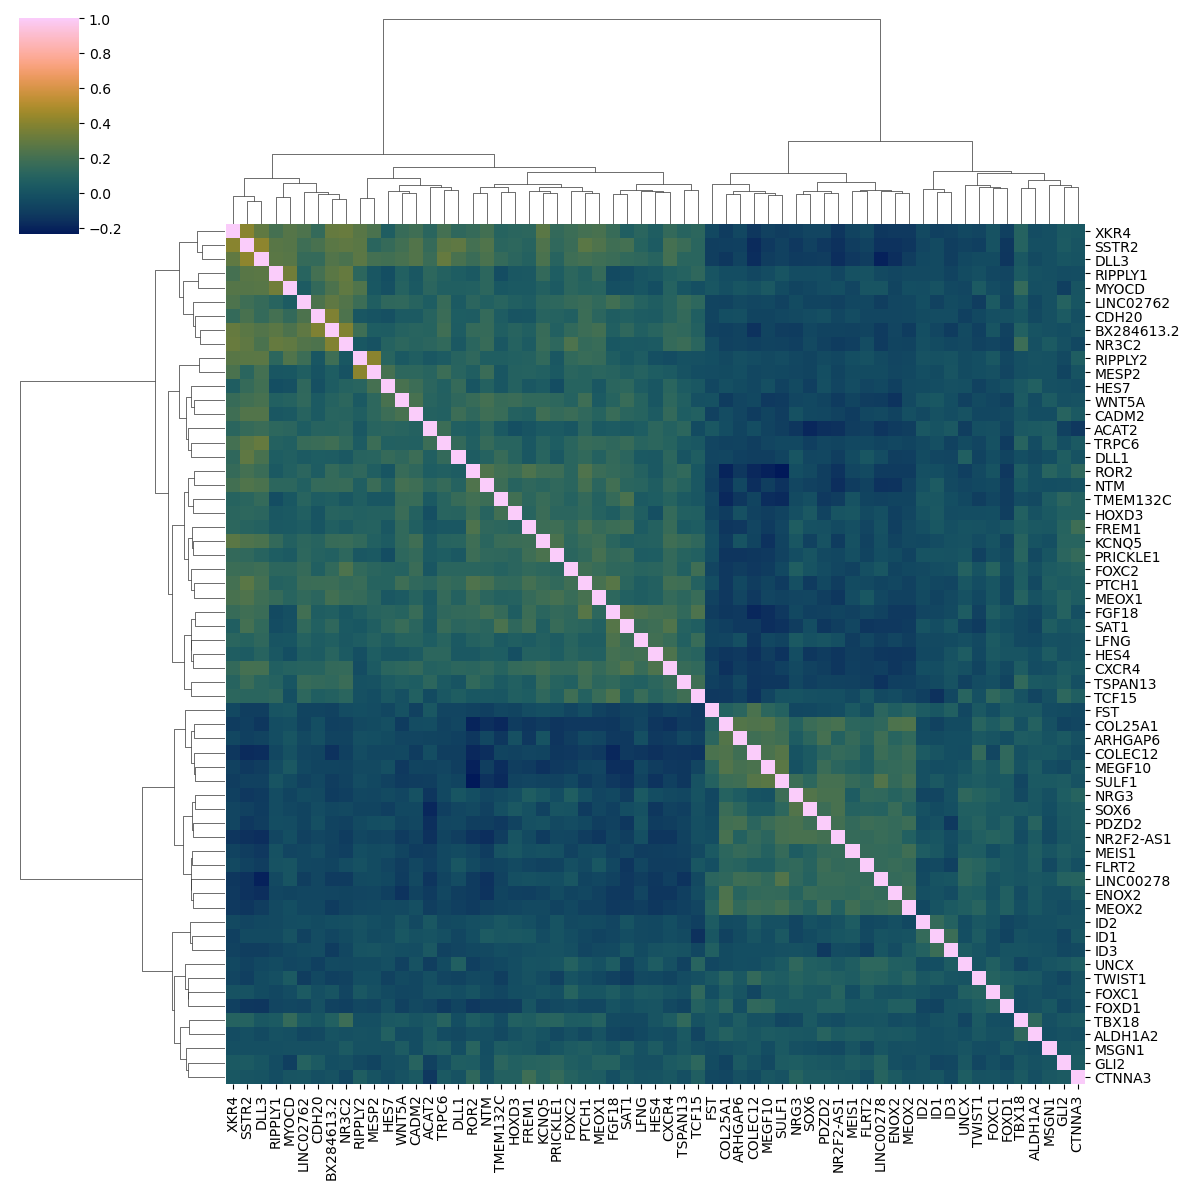

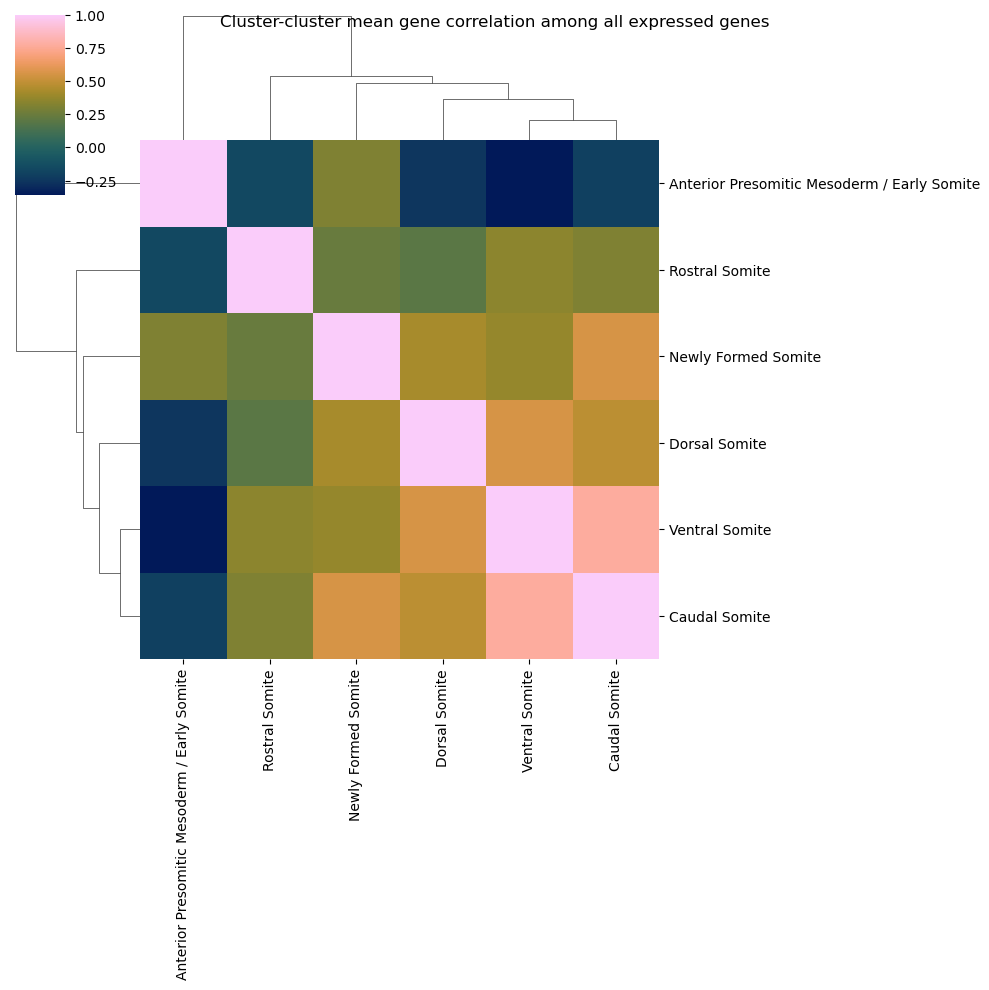

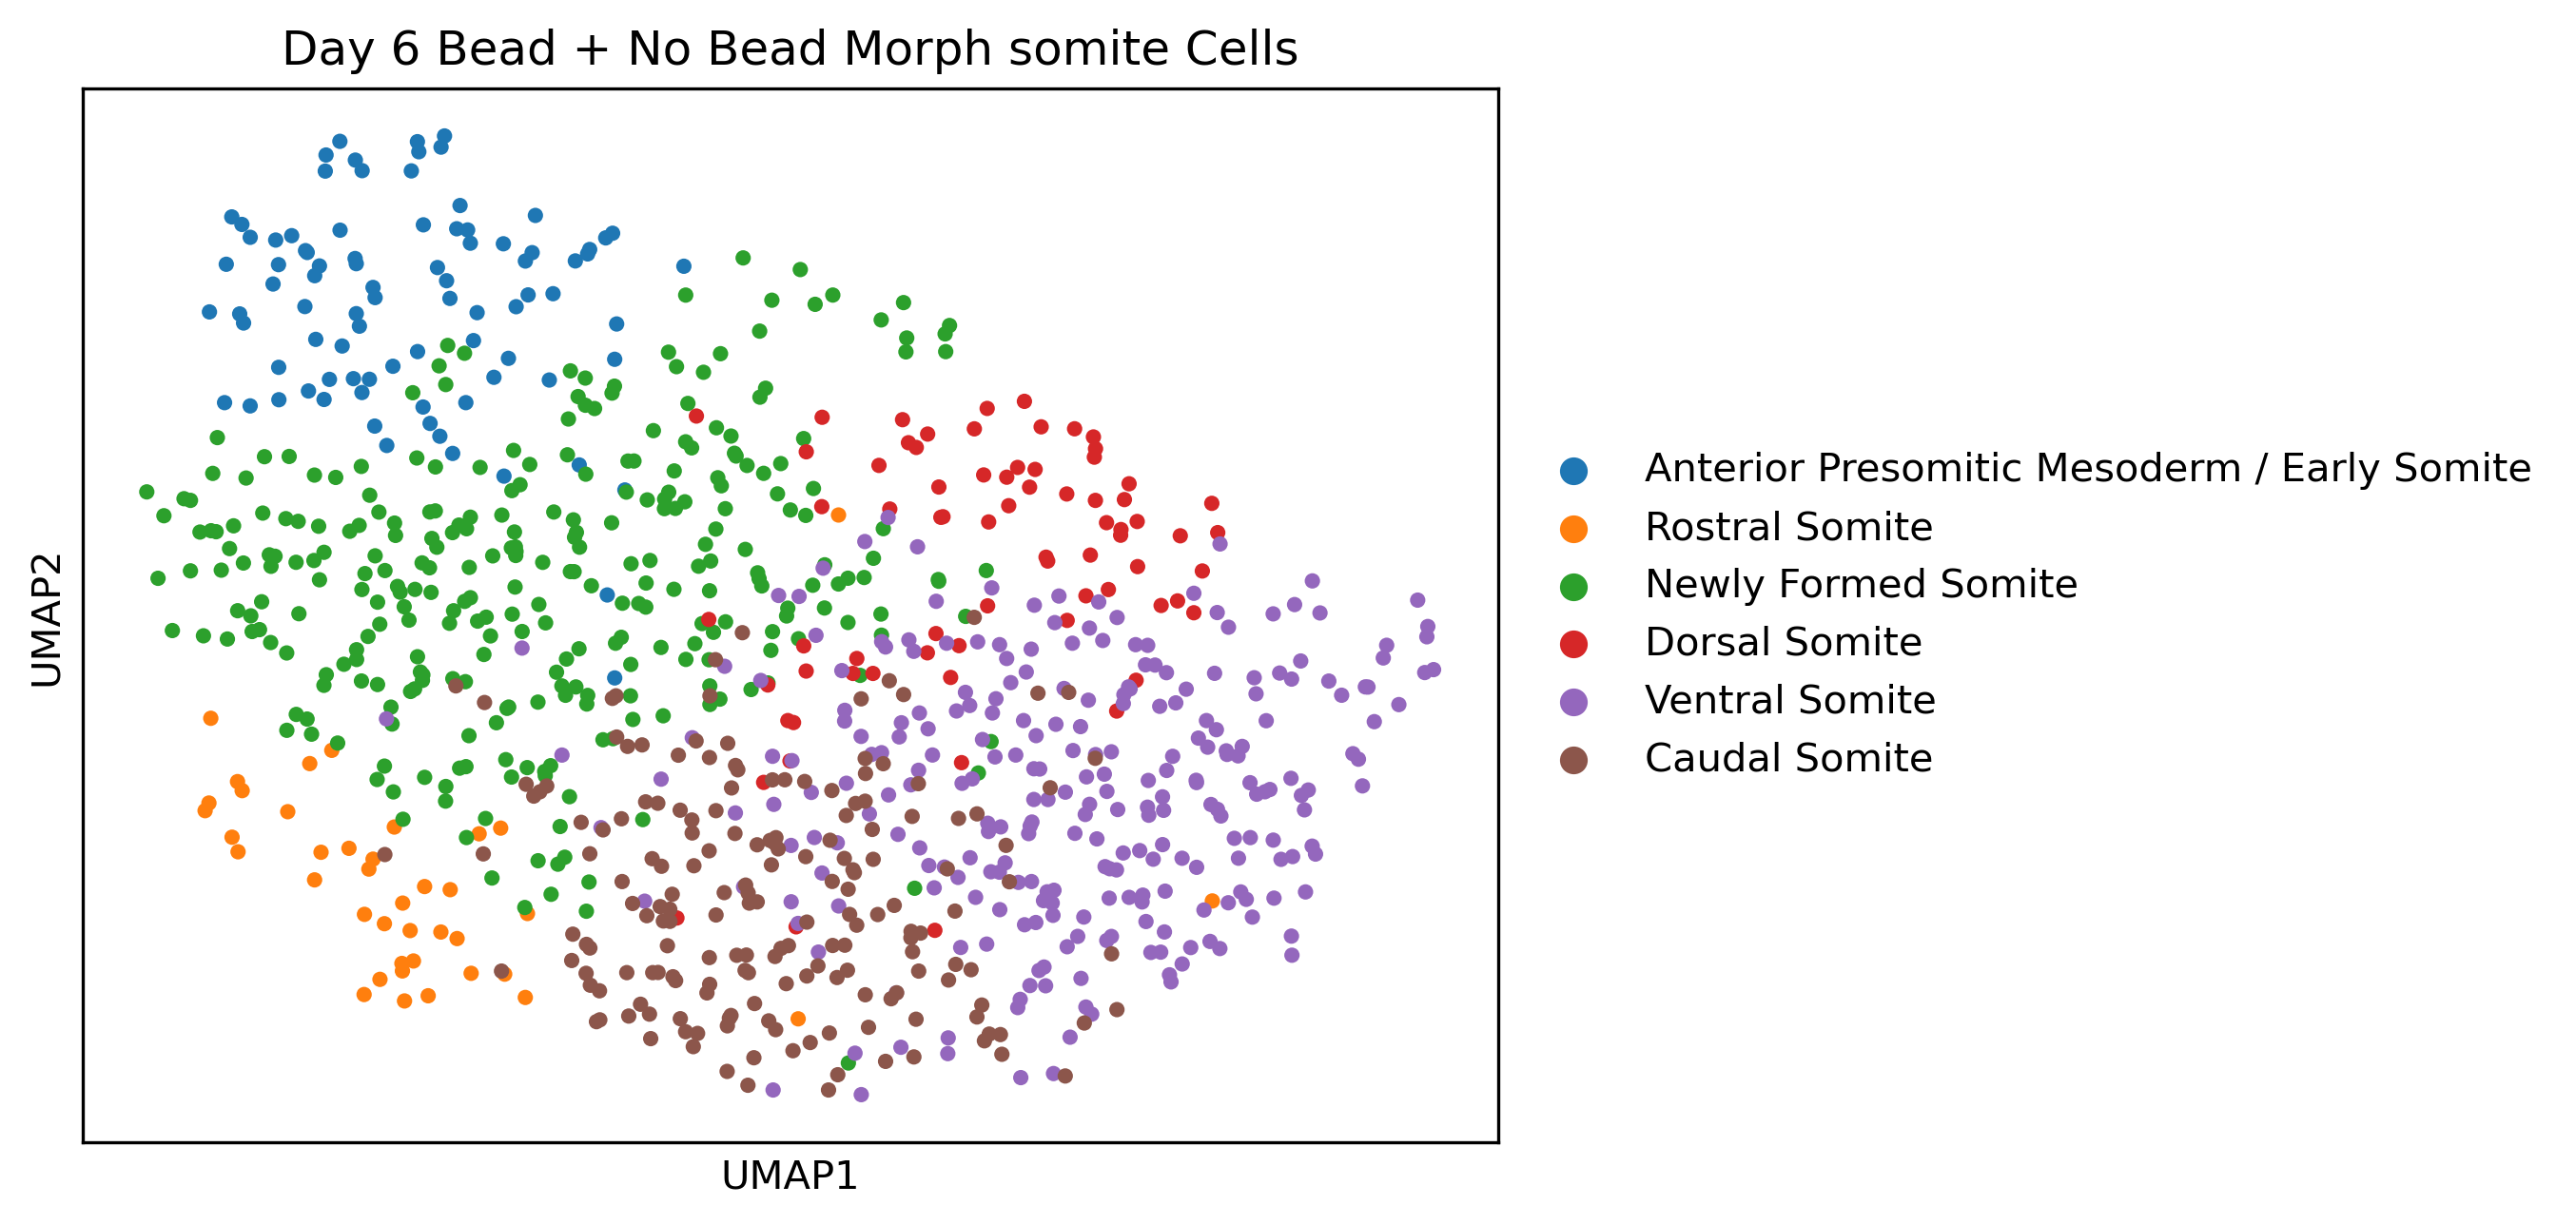

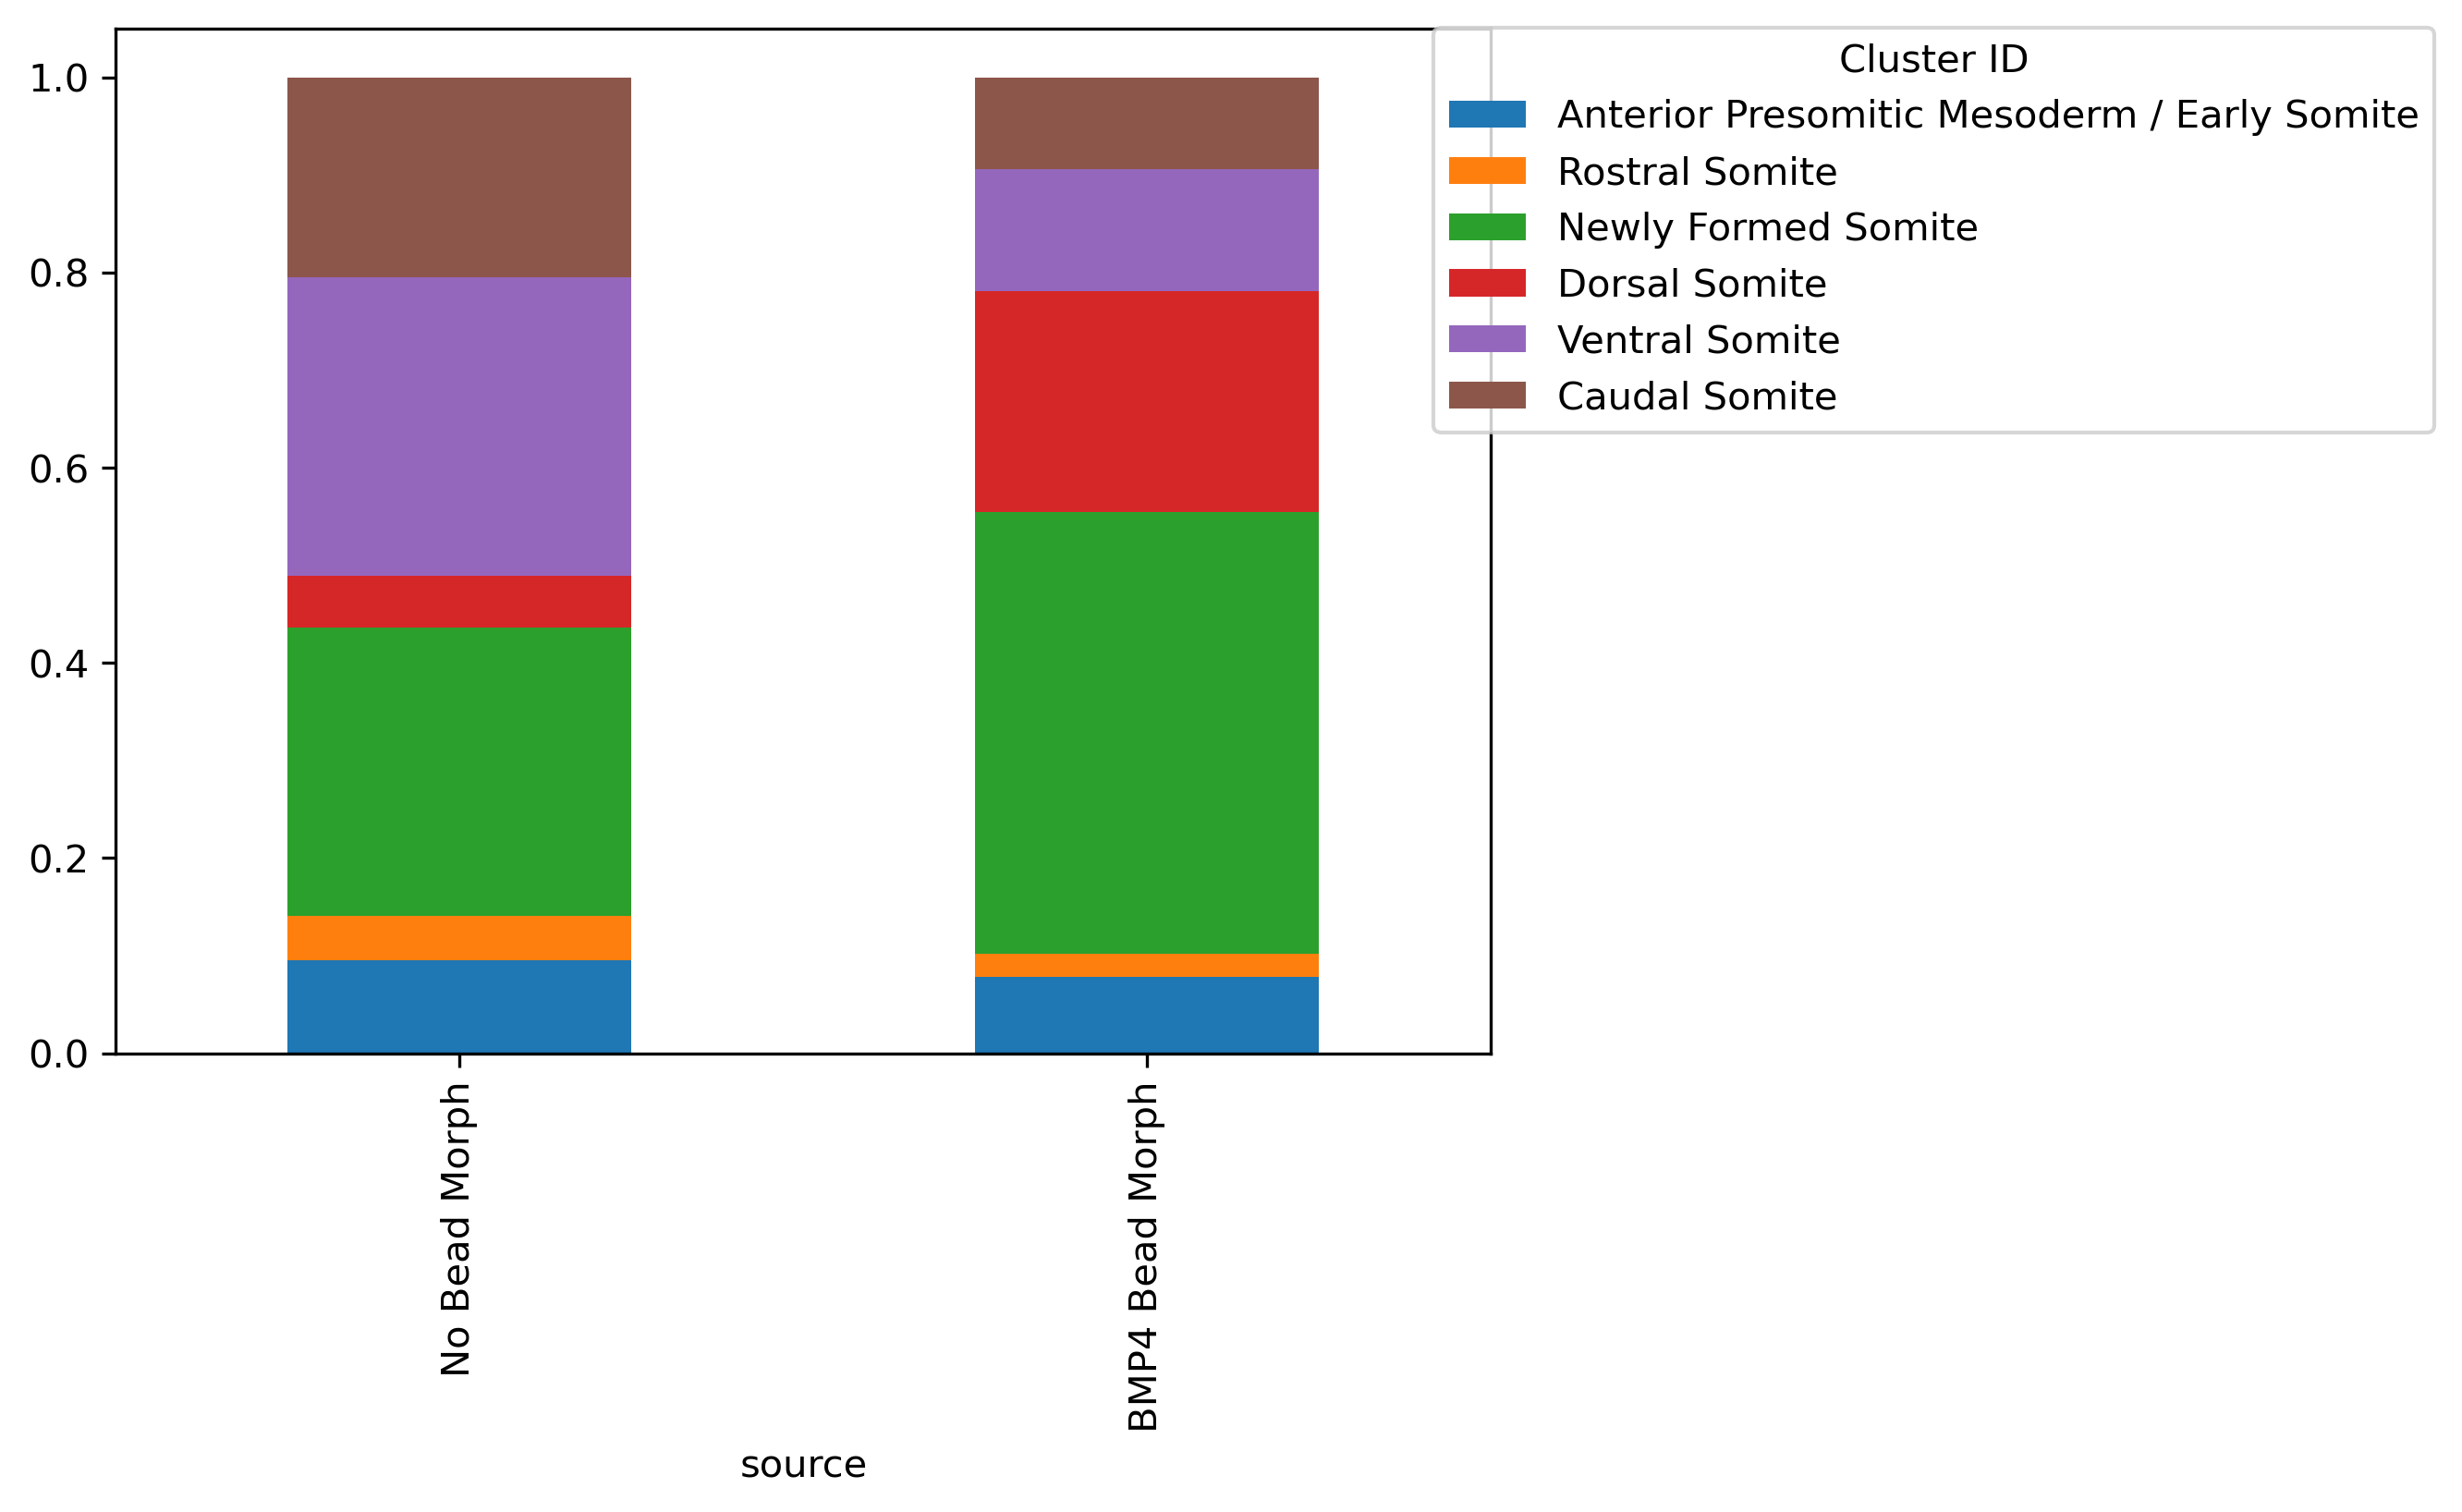

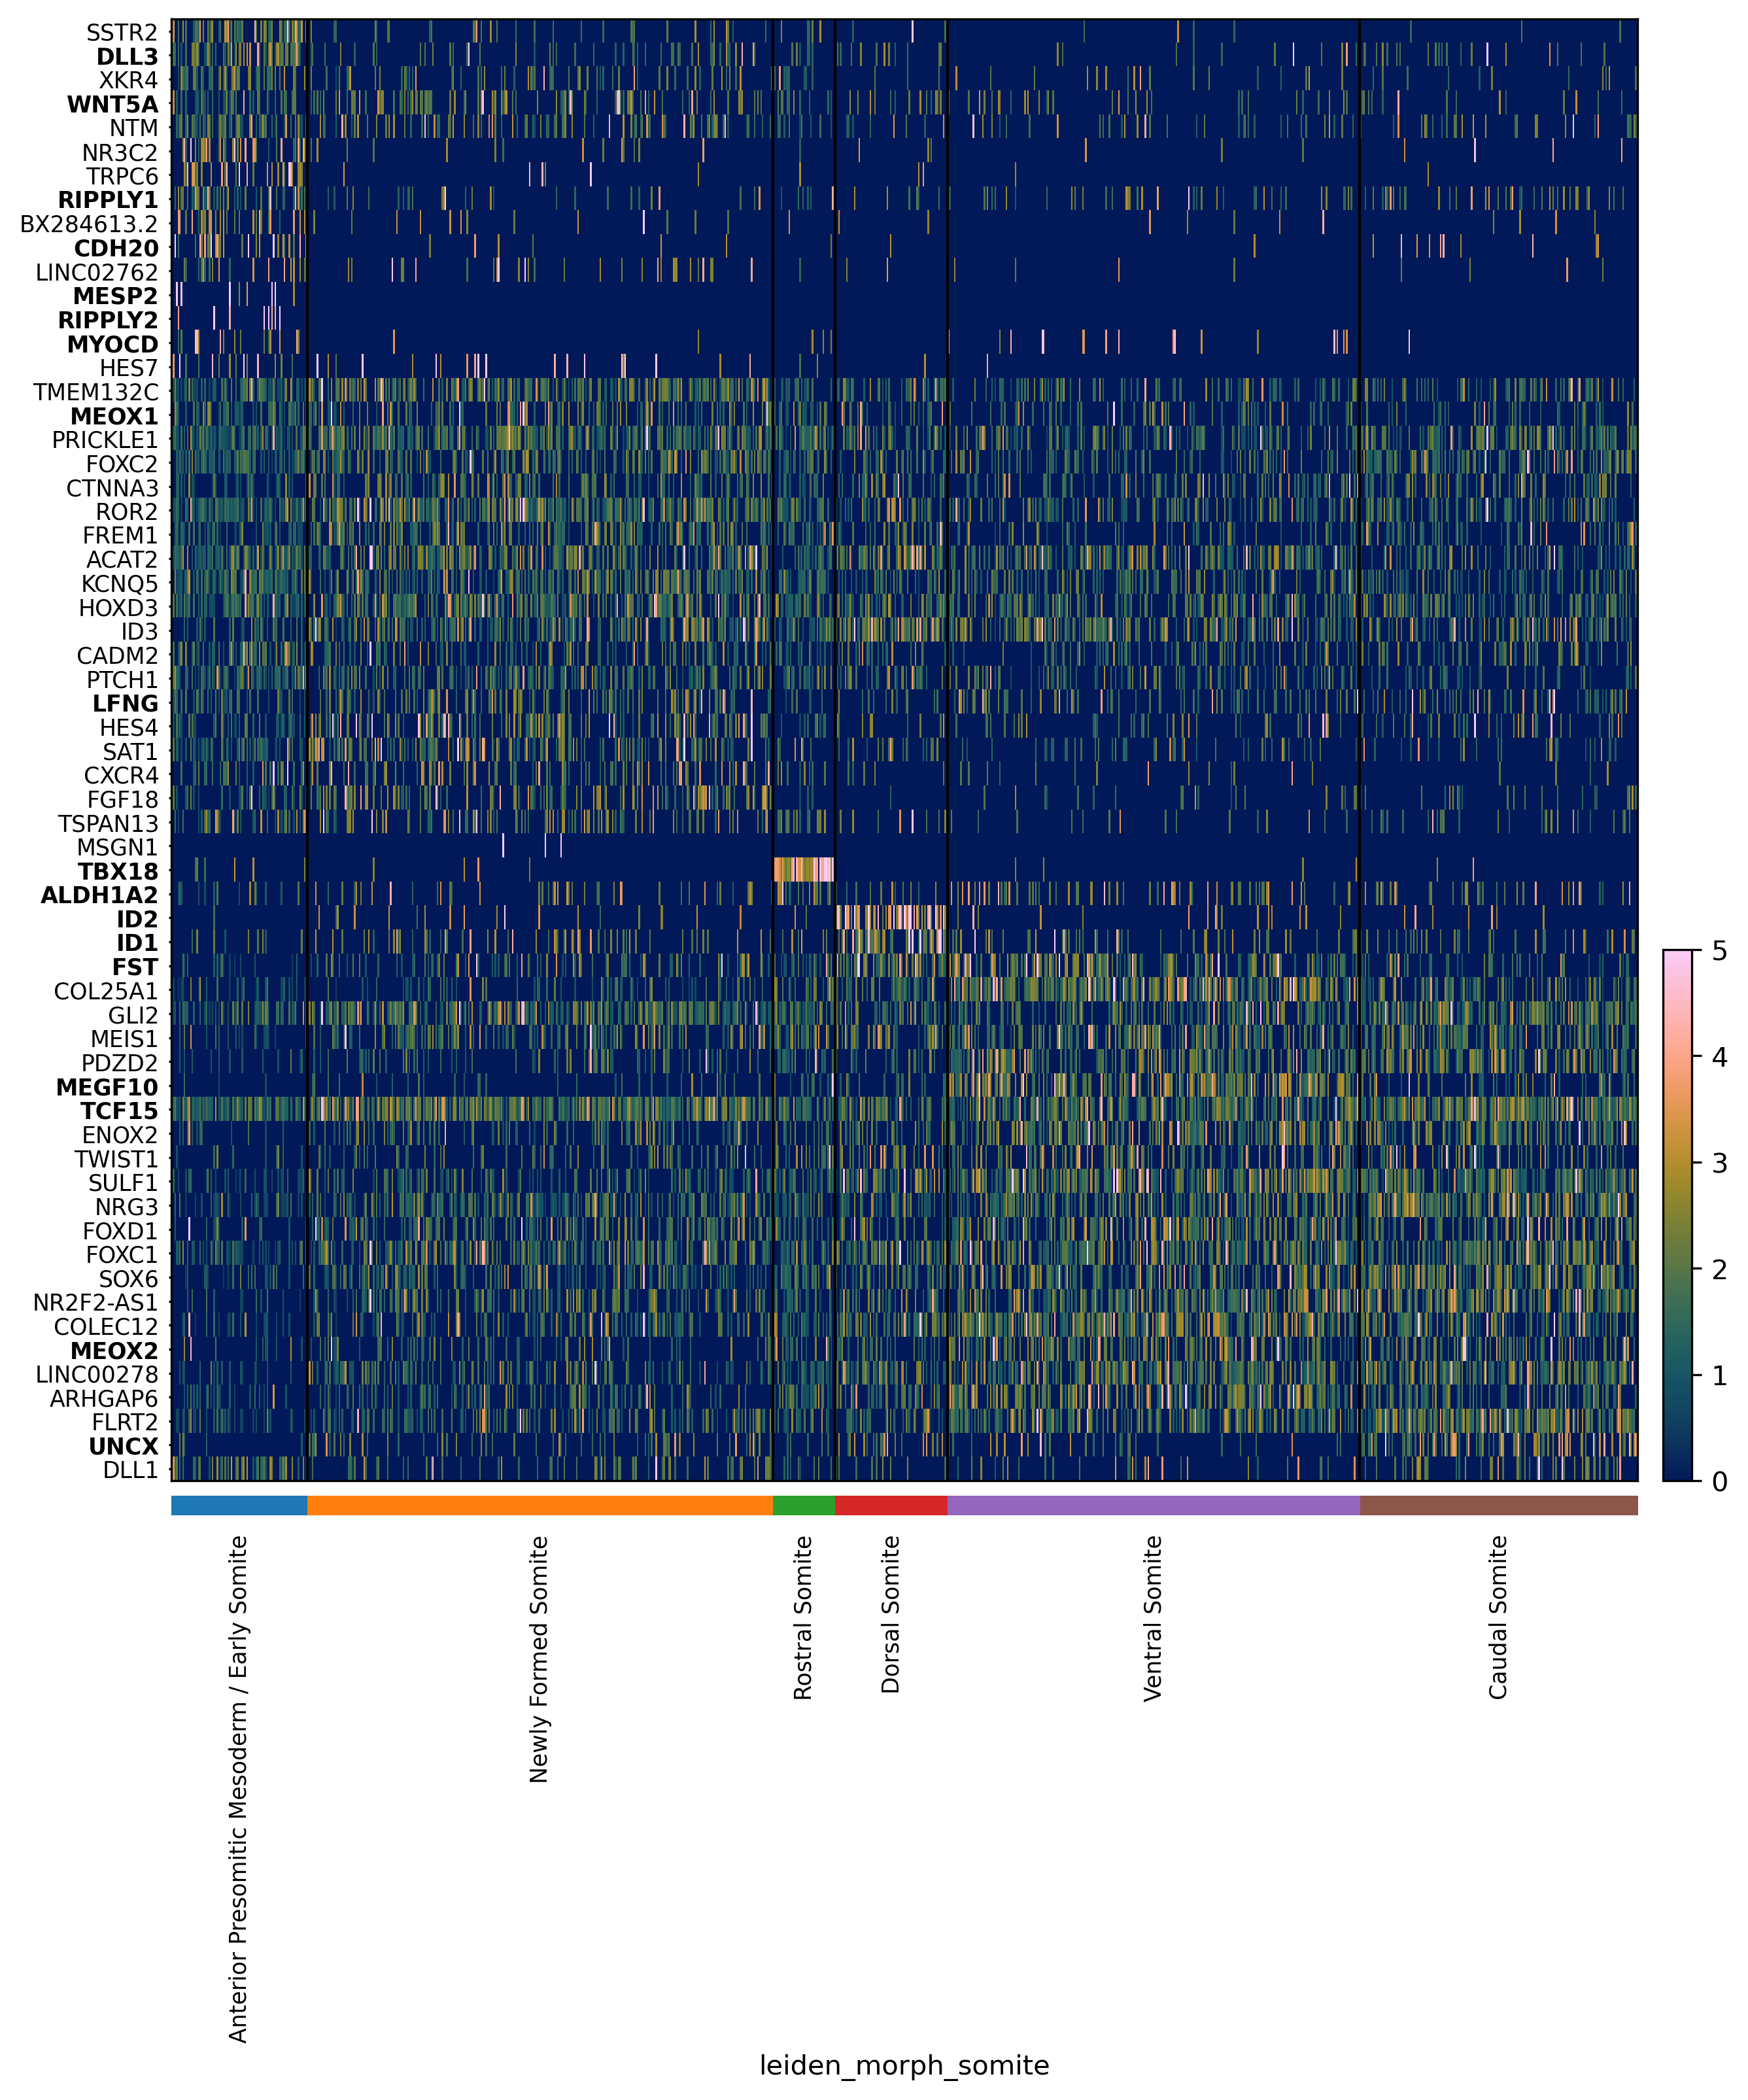

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


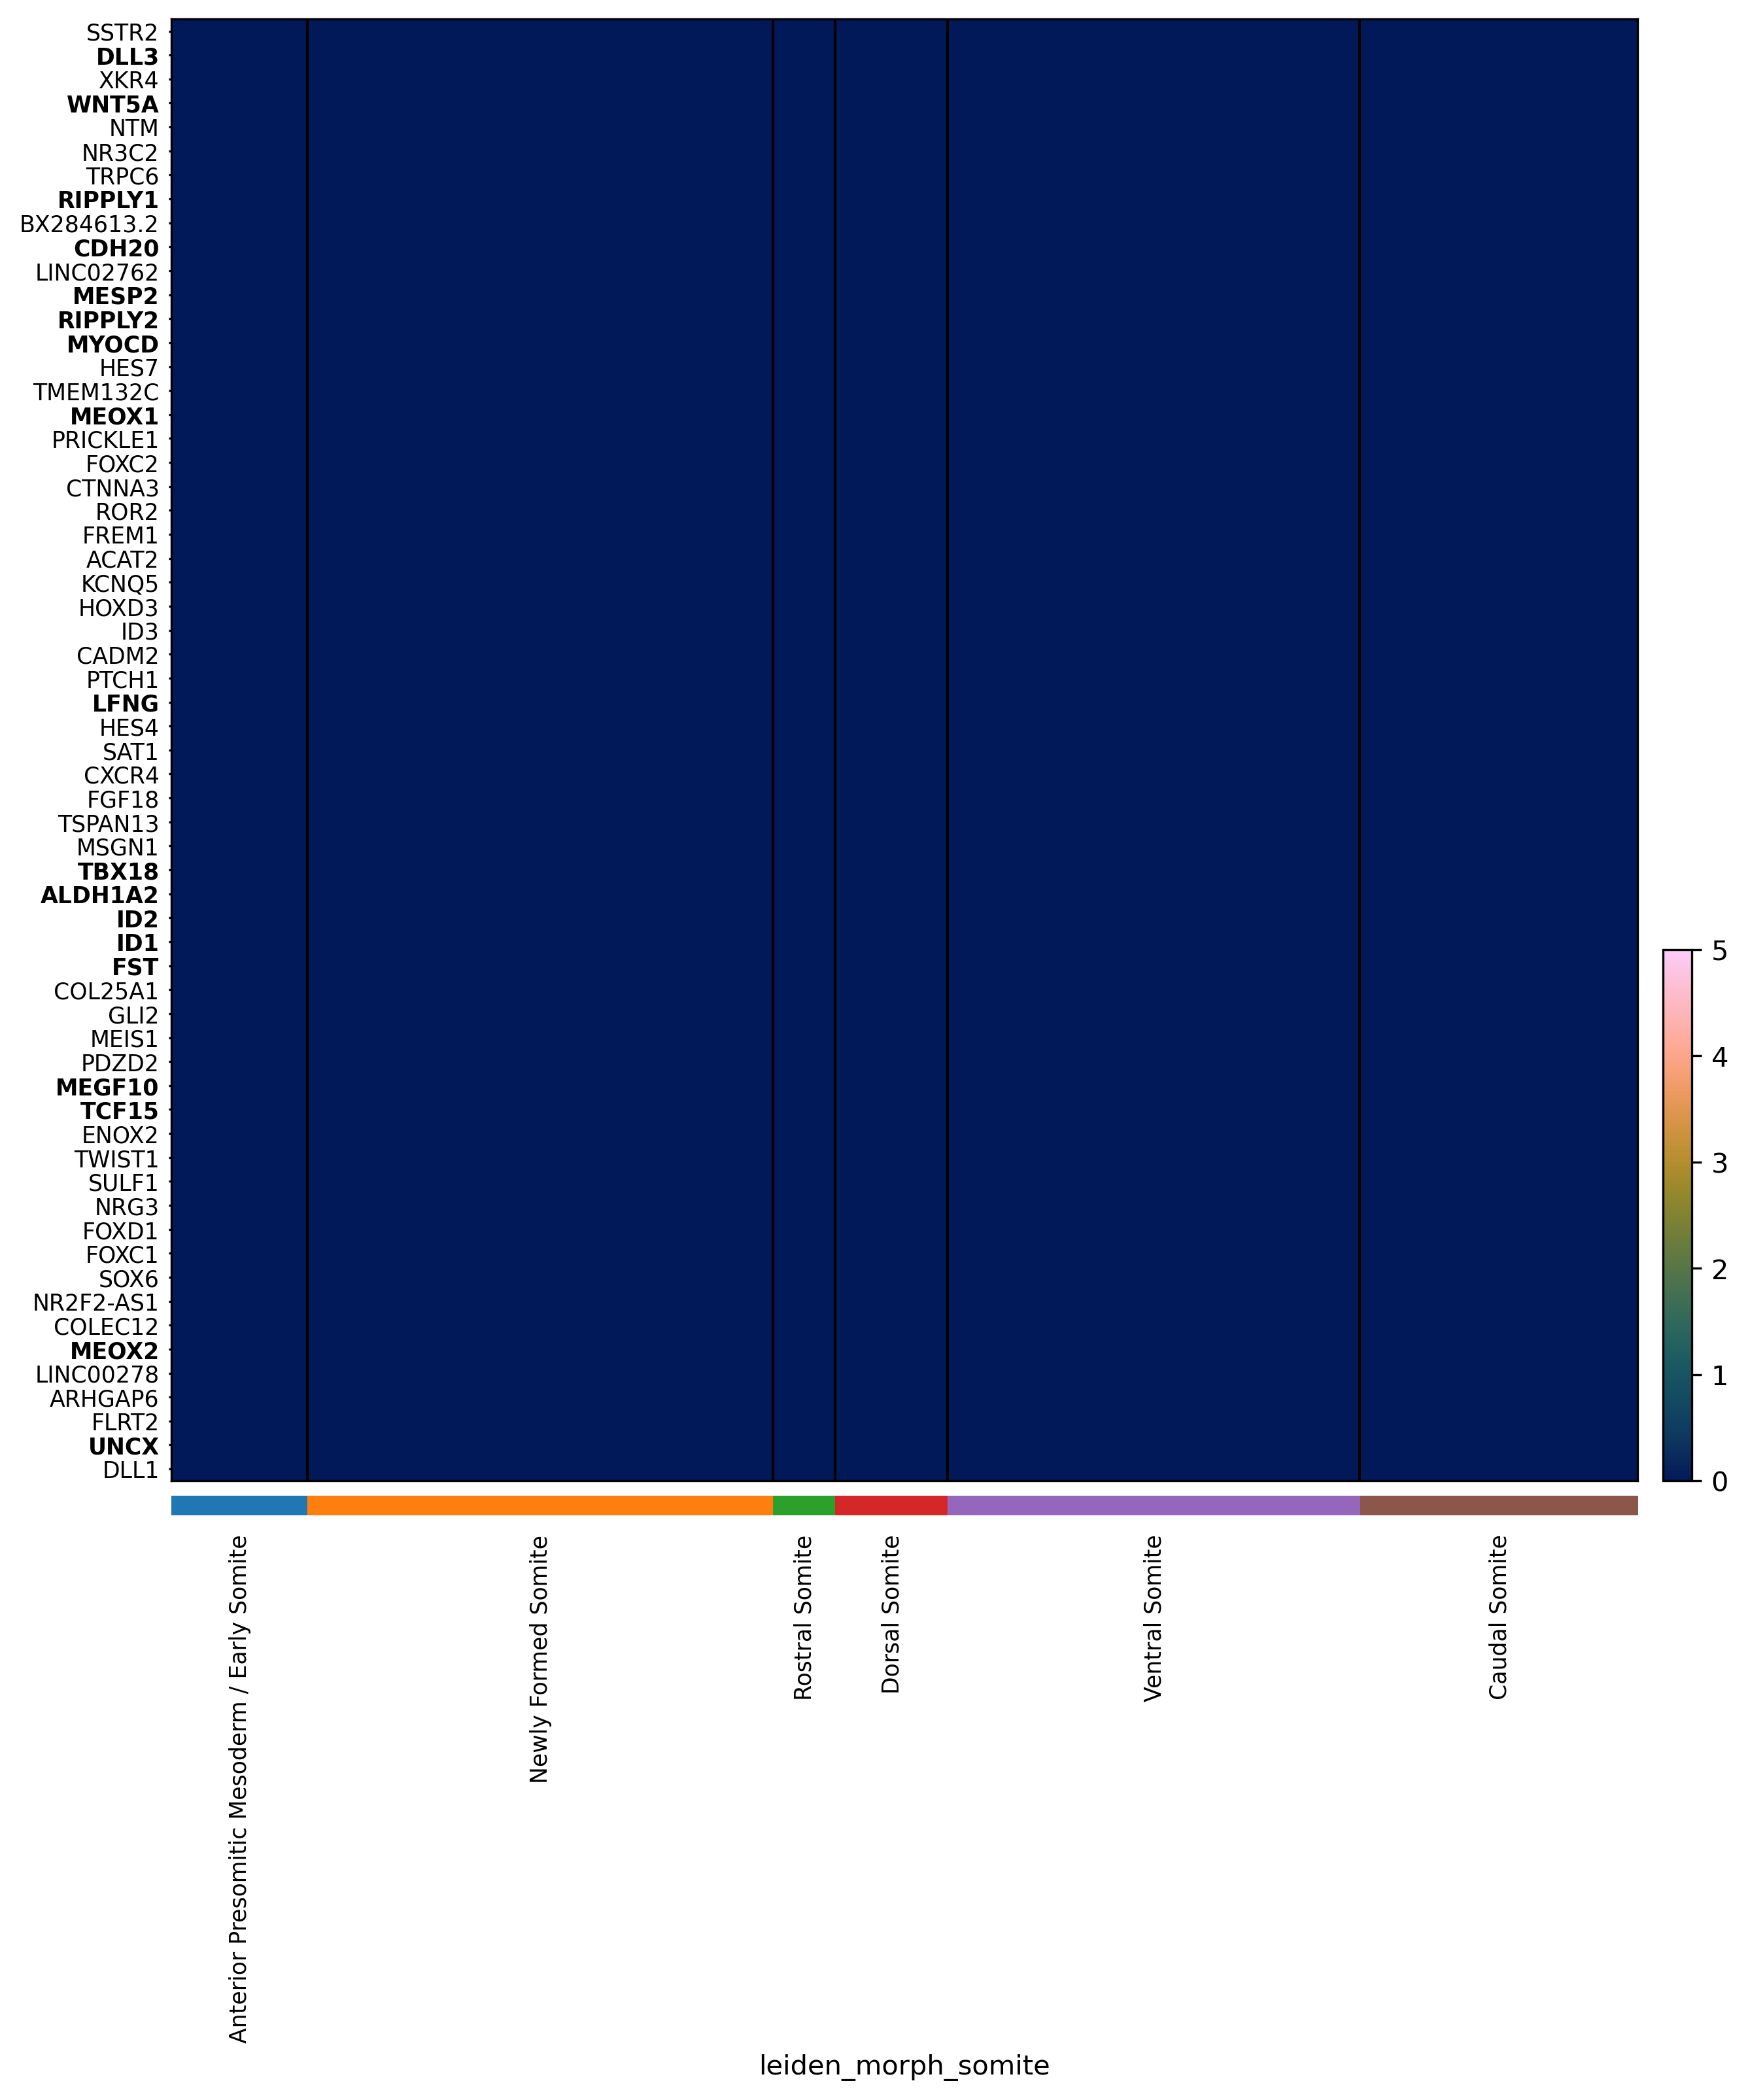

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


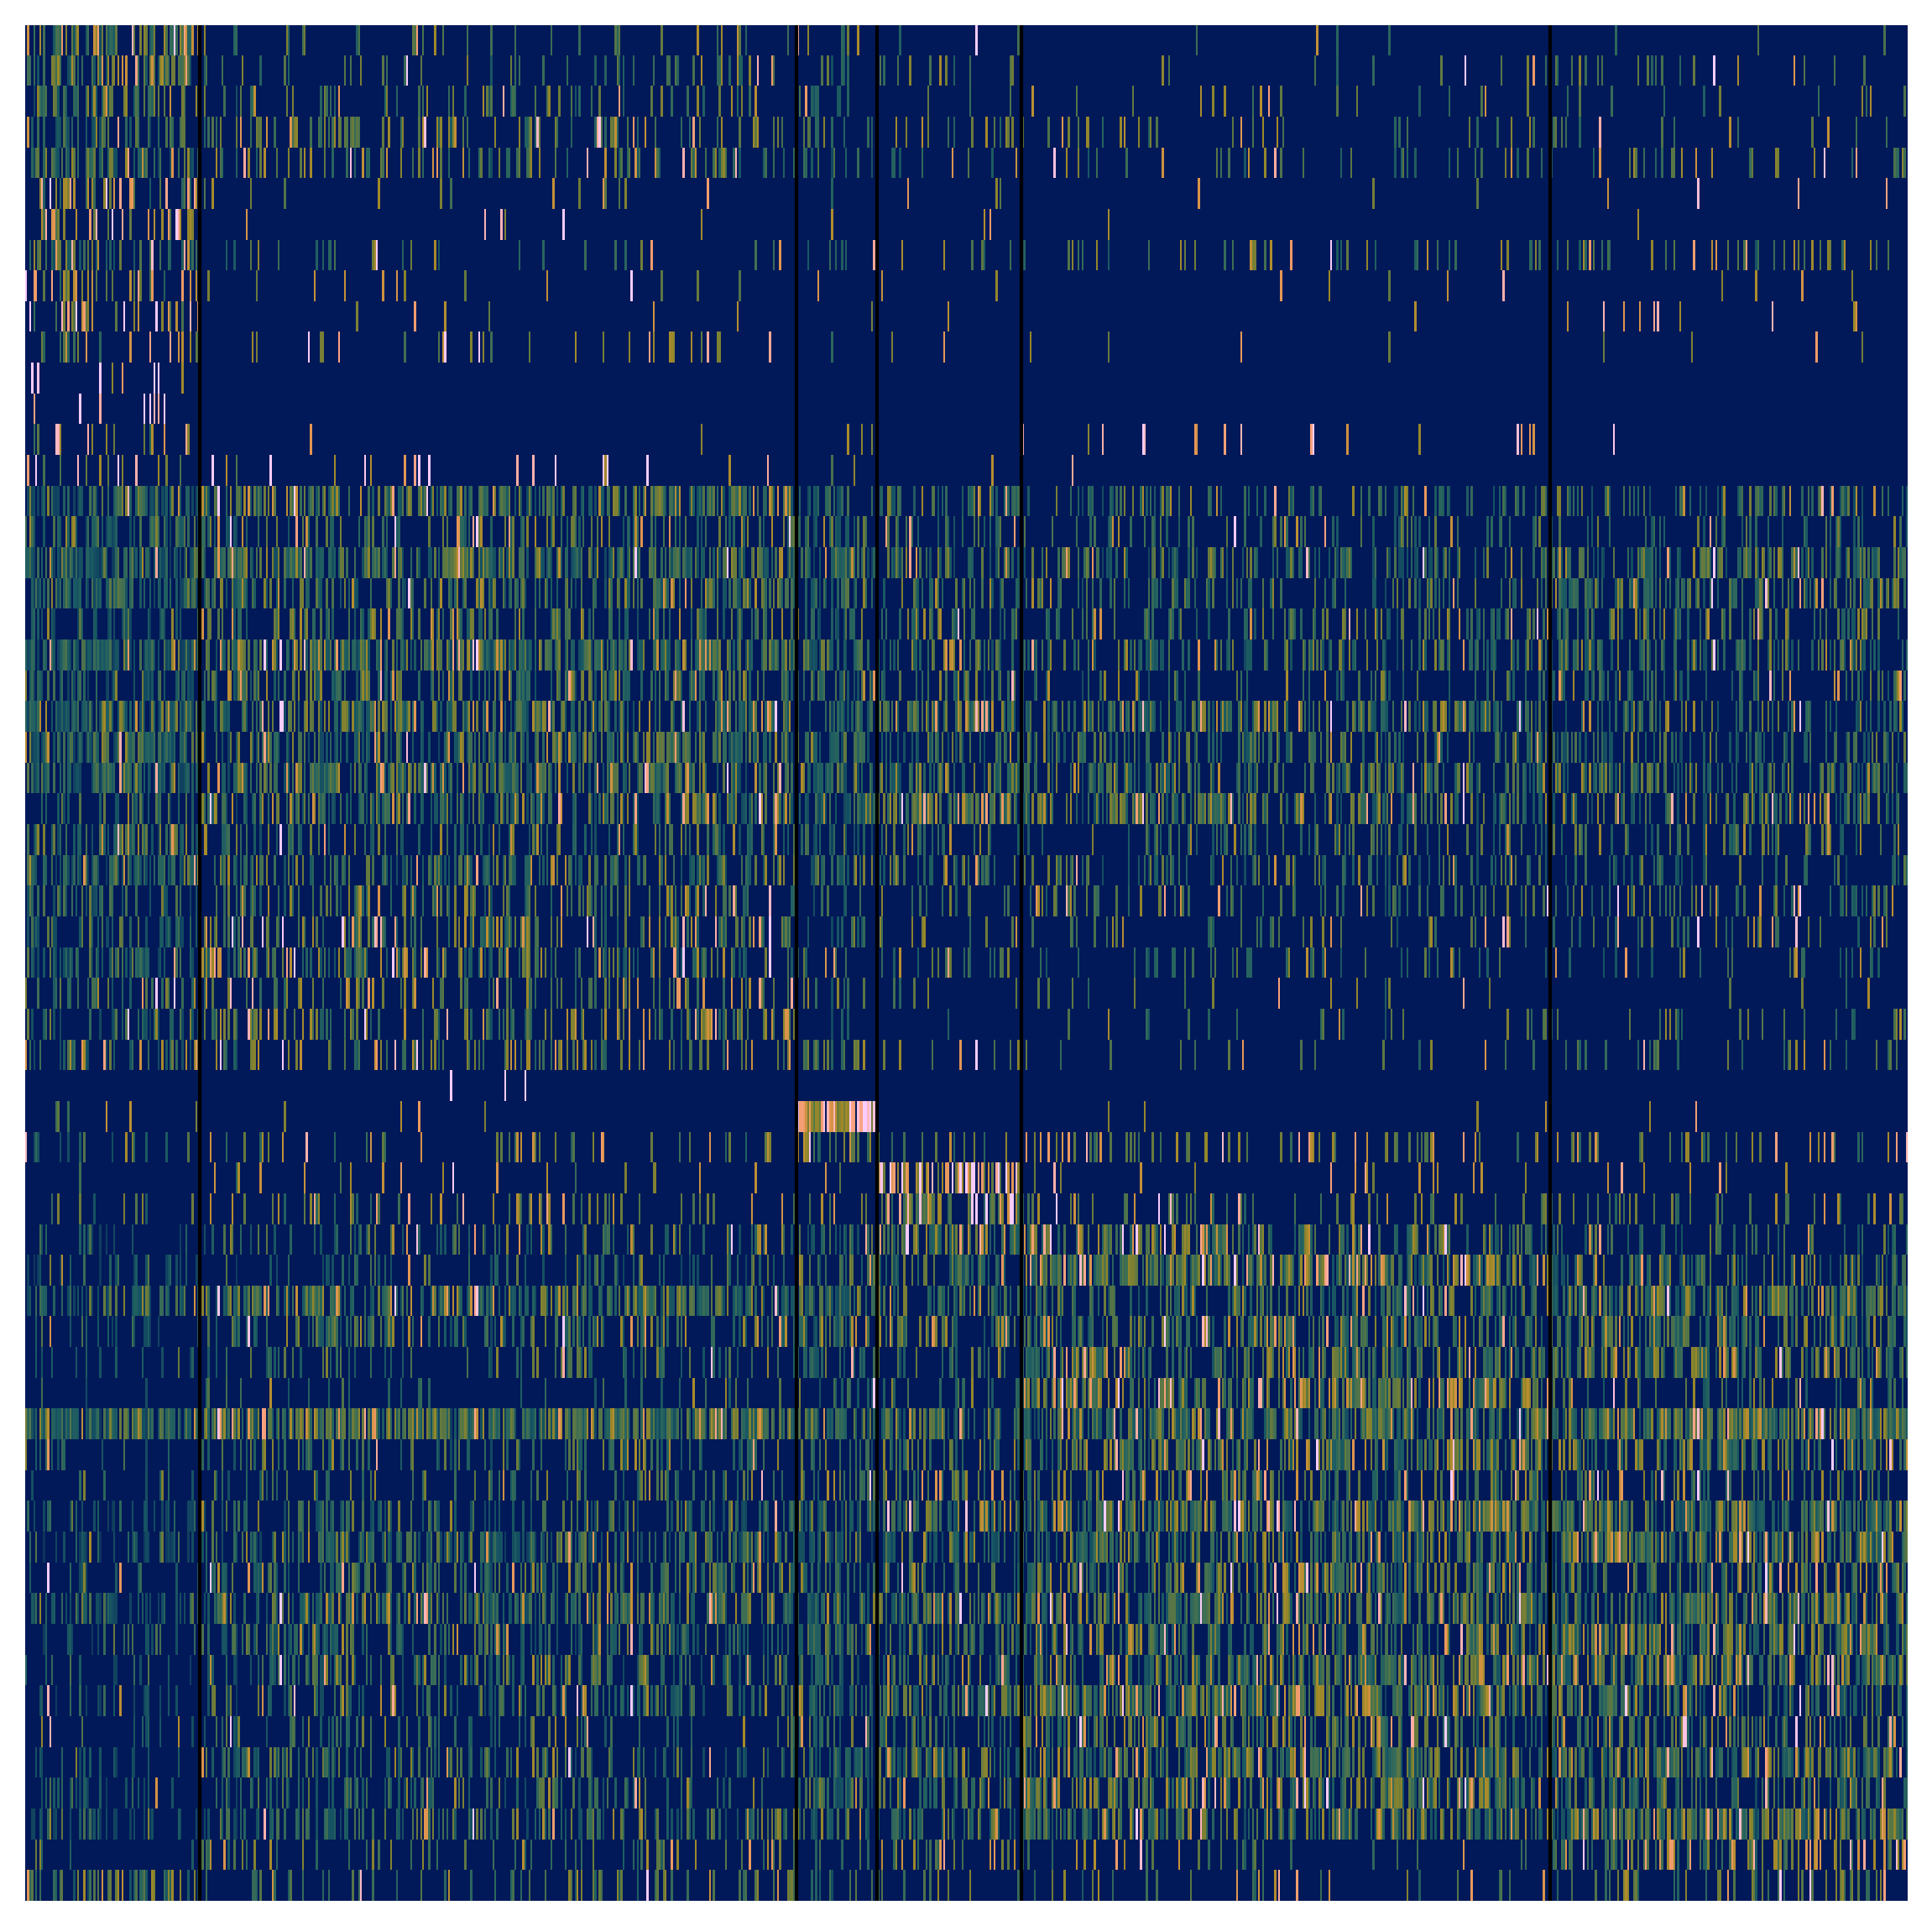

In [ ]:
# Notebook cell 155
genes_cellcycle = [
    "MKI67",
    "CENPE",
    "SGO2",
    "KIF14",
    "PIF1",
    "NDC80",
    "CDCA8",
    "PLK1",
    "AURKA",
    "UBE2C",
    "ASPM",
    "TOP2A",
    "TPX2",
    "NUSAP1",
    "CDC20",
    "CKS2",
    "KPNA2",
    "TUBB4B",
    "DLGAP5",
    "BIRC5",
    "HMMR",
    "CCNB1",
    "ARL6IP1",
    "PTTG1",
    "UBE2S",
    "DUT",
    "HELLS",
    "CLSPN",
    "RRM2",
    "PCLAF",
    "TYMS",
    "KIF18B",
    "SMC4",
    "HIST1H4C",
    "DIAPH3",
    "RFC3",
    "MIR924HG",
    "MIS18BP1",
    "TUBA1C",
    "CDK1",
    "CENPA",
    # extra genes added after mesoderm subclustering, were not already in SMD gene list
    "KIF11",
    "ECT2",
    "KNL1",
    "NEK2",
    "CEP55",
    "PSRC1",
    "CDCA3",
    "CCNA2",
    "GTSE1",
    "CENPF",
    "CKS1B",
    "MELK",
    "CDCA5",
    # Added 4/8 during LPM sub-subclustering
    "MCM4",
    "HIST1H1E",
    "BRCA2",
    "TRIM66",
    "C1orf112",
    "POLD3",
    "KIF23",
    # Added 4/8 part 2
    "CDKAL1",
    "RAD51AP1",
    "RANBP1",
    "CDCA2",
    "CAND2",
    "PCLAF",
    "EIF5A",
    "SRSF2",
    "GINS1",
    "GINS2",
    # Added 4/9 Neuron subclustering
    "ncAPG2",
    "CCND1",
    "ATAD2",
    "UBE2T",
    "CENPK",
    "LAPTM4B",
    "CCND2",
    "MED13",
    "ZNF37A",
    "PTPN14",
    # 4/10 Neural Crest
    "ncAPG",
    "TTK",
    "KIF4A",
    "KIF18A",
    "CDKN3",
    "CEP70",
    "BRIP1",
    "SPC25",
    "KIFC1",
    "NSD2",
    "BUB1",
    "BUB1B",
    "ANP32E",
    "HMGB3",
    "PCNA",
    "CENPP",
    # 4/10 Roof plate
    "CCT5",
    "KIF15",
    "CSRP2",
    "ORC6",
    "HMGB2",
]


# Notebook cell 156
NOTEBOOK_DPI = 110

# As done for LPM subclustering, we repeat gene filtering on the subset of somite cluster cells alone
adata_morph_somite = adata_morph_raw.copy()

# Filter for cells more than 5k reads
somite_minimum_reads = 5000
sc.pp.filter_cells(adata_morph_somite, min_counts=somite_minimum_reads)

# Downsample such that each cell has 10k reads
sc.pp.downsample_counts(
    adata_morph_somite,
    counts_per_cell=somite_minimum_reads,
    replace=True,
    random_state=0,
)

adata_morph_somite.obs["leiden_morph"] = adata_morph_with_clusters.obs[
    "leiden_morph"
].reindex(adata_morph_somite.obs_names)
missing_cluster_labels = int(adata_morph_somite.obs["leiden_morph"].isna().sum())
if missing_cluster_labels:
    print(
        f"Dropping {missing_cluster_labels} cells not present in adata_morph_with_clusters "
        "before coarse-cluster subsetting."
    )
    adata_morph_somite = adata_morph_somite[
        adata_morph_somite.obs["leiden_morph"].notna()
    ].copy()

# Notebook cell 157
somite_clusters = ["Early Somite", "Mature Somite"]

# Select cells that are in somite clusters
adata_morph_somite = adata_morph_somite[
    adata_morph_somite.obs.leiden_morph.isin(somite_clusters).values
].copy()

# Log-transform read counts
sc.pp.log1p(adata_morph_somite)

# For SMD analysis:
# Filter for log-transformed genes with mean value greater than 0.05 and standard deviation greater than 0.05
adata_morph_somite_filtered = filter_genes(
    adata_morph_somite, mean_cutoff=0.05, std_cutoff=0.05
)
# Normalize each gene to have unit variance in expression
adata_morph_somite_filtered = normalize_unit_variance(adata_morph_somite_filtered)

# Notebook cell 158
# Filter for coefficient of variation (std deviation / mean) > 1
# Since we have normalized to unit variance this is just a mean cutoff < 1
counts = adata_morph_somite_filtered.X
cv_mask = np.mean(counts, axis=0).transpose() < 1
adata_morph_somite_filtered = adata_morph_somite_filtered[:, cv_mask].copy()

# Notebook cell 159
# Save pre-processed expression data to .npz file, for input to SMD on cluster
somite_stage_path = RESULTS_DIR / "intermediates" / "04_somite_subclustering"
somite_stage_path.mkdir(parents=True, exist_ok=True)
legacy_somite_input_path = somite_stage_path / "morph_somite4.03.npz"
canonical_somite_input_path = somite_stage_path / "trunk_morph_somite__smd_input.npz"
for _path in [legacy_somite_input_path, canonical_somite_input_path]:
    scipy.sparse.save_npz(_path, adata_morph_somite_filtered.X)
recommended_n_sub = int(round(0.8 * len(adata_morph_somite_filtered)))
save_json(
    {
        "stage": "04_somite_subclustering",
        "subset_name": "somite",
        "subset_clusters": somite_clusters,
        "minimum_reads": somite_minimum_reads,
        "legacy_smd_input_file": legacy_somite_input_path.name,
        "canonical_smd_input_file": canonical_somite_input_path.name,
        "n_cells_after_preprocessing": int(adata_morph_somite_filtered.n_obs),
        "n_genes_after_preprocessing": int(adata_morph_somite_filtered.n_vars),
        "recommended_n_sub": recommended_n_sub,
        "status": "ready_for_smd",
    },
    somite_stage_path / "pre_smd_input_meta.json",
)
print(
    str(len(adata_morph_somite_filtered))
    + " cells after pre-processing\n"
    + str(adata_morph_somite_filtered.shape[1])
    + " genes after preprocessing\nRecommended n_sub ≈ "
    + str(recommended_n_sub)
)

# Notebook cell 160
# For downstream analysis after SMD:
# Only filter genes for non-zero mean and standard deviation:
adata_morph_somite_nofilter = adata_morph_somite.copy()
adata_morph_somite = filter_genes(adata_morph_somite, mean_cutoff=0, std_cutoff=0)
adata_morph_somite = normalize_unit_variance(adata_morph_somite)

# Notebook cell 162
# Load modern somite SMD runs from local trunk_main_dev results
somite_smd_run_order = ["001", "002"]
somite_smd_run_dirs = {
    "001": PROJECT_ROOT / "trunk_main_dev" / "results" / "smd_runs" / "trunk_morph_somite__run001",
    "002": PROJECT_ROOT / "trunk_main_dev" / "results" / "smd_runs" / "trunk_morph_somite__run002",
}
somite_smd_runs = {
    run_id: load_npy(
        somite_smd_run_dirs[run_id] / f"z_trunk_morph_somite__smd_input_{run_id}.npy"
    )
    for run_id in somite_smd_run_order
}
selected_somite_smd_run = "002"
somite_smd_run_name = f"trunk_morph_somite__run{selected_somite_smd_run}"
somite_smd_zscore_name = f"z_trunk_morph_somite__smd_input_{selected_somite_smd_run}.npy"
z_scores_morph_somite = somite_smd_runs[selected_somite_smd_run]

if len(z_scores_morph_somite) != adata_morph_somite_filtered.n_vars:
    raise ValueError(
        "Somite SMD z-score length does not match filtered gene space: "
        f"{len(z_scores_morph_somite)} vs {adata_morph_somite_filtered.n_vars}"
    )

adata_morph_somite_filtered.var["z_score_morph_somite"] = z_scores_morph_somite
adata_morph_somite_filtered.var["log1p_z_score_morph_somite"] = np.log1p(
    adata_morph_somite_filtered.var["z_score_morph_somite"]
)


def parse_smd_run_config(run_dir):
    cfg = {}
    text = (run_dir / "ray_SMD.py").read_text()
    for key in ["n_sub", "trials", "kmax", "k_prior_min"]:
        value = None
        for line in text.splitlines():
            stripped = line.strip()
            if stripped.startswith(f"{key} ="):
                value = stripped.split("=", 1)[1].strip()
                break
        cfg[key] = value
    return cfg


somite_run_summary_rows = []
for run_id in somite_smd_run_order:
    z = somite_smd_runs[run_id]
    cfg = parse_smd_run_config(somite_smd_run_dirs[run_id])
    somite_run_summary_rows.append(
        {
            "run_id": run_id,
            "n_sub": cfg.get("n_sub"),
            "trials": cfg.get("trials"),
            "kmax": cfg.get("kmax"),
            "k_prior_min": cfg.get("k_prior_min"),
            "n_genes_z_gt_2": int((z > 2).sum()),
            "max_z": float(z.max()),
        }
    )
somite_run_summary = pd.DataFrame(somite_run_summary_rows)
display(somite_run_summary)

comparison_run_ids = [
    run_id for run_id in somite_smd_run_order if run_id != selected_somite_smd_run
]


def somite_run_difference_table(gene_indices):
    rows = []
    for gene_idx in sorted(gene_indices):
        gene_id = str(adata_morph_somite_filtered.var_names[gene_idx])
        row = {
            "gene_id": gene_id,
            "gene_symbol": adata_morph_somite_filtered.var.iloc[gene_idx].get(
                "gene_symbol", ""
            ),
            "gene_symbol_original": adata_morph_somite_filtered.var.iloc[gene_idx].get(
                "gene_symbol_original", ""
            ),
            "selected_z": float(z_scores_morph_somite[gene_idx]),
        }
        for run_id in comparison_run_ids:
            row[f"run_{run_id}_z"] = float(somite_smd_runs[run_id][gene_idx])
        rows.append(row)
    if not rows:
        return pd.DataFrame(
            columns=[
                "gene_id",
                "gene_symbol",
                "gene_symbol_original",
                "selected_z",
                *[f"run_{run_id}_z" for run_id in comparison_run_ids],
            ]
        )
    return pd.DataFrame(rows).sort_values("selected_z", ascending=False)


selected_run_gene_set = set(np.flatnonzero(z_scores_morph_somite > 2))
comparison_run_tables = {}
for run_id in comparison_run_ids:
    run_gene_set = set(np.flatnonzero(somite_smd_runs[run_id] > 2))
    selected_only_df = somite_run_difference_table(selected_run_gene_set - run_gene_set)
    run_only_df = somite_run_difference_table(run_gene_set - selected_run_gene_set).rename(
        columns={"selected_z": f"run_{selected_somite_smd_run}_z"}
    )
    if f"run_{run_id}_z" in run_only_df.columns:
        run_only_df = run_only_df.sort_values(f"run_{run_id}_z", ascending=False)
    comparison_run_tables[run_id] = {
        "selected_only": selected_only_df,
        "reference_only": run_only_df,
    }
    print(
        f"Run {selected_somite_smd_run}-only genes at z > 2 relative to run {run_id}: "
        f"{len(selected_only_df)}"
    )
    display(selected_only_df)
    print(
        f"Run {run_id}-only genes at z > 2 relative to run {selected_somite_smd_run}: "
        f"{len(run_only_df)}"
    )
    display(run_only_df)

# Plot top morph_somite SMD z-scores
smd_cutoff = 10.0
plt.figure(figsize=(12, 4))
plt.hlines(smd_cutoff, -1, 2000, "r")
plt.plot(sorted(z_scores_morph_somite)[::-1], "k.", markersize=5)
plt.yscale("log")
plt.ylim(0.01, 1.5 * z_scores_morph_somite.max())
plt.xlim(-1, 1000)
plt.ylabel("morph_somite z-score")
print(
    f"\n{int((z_scores_morph_somite > smd_cutoff).sum())} morph_somite genes with z_score >= cutoff"
)
plt.show()

# Notebook cell 163
adata_morph_somite_filtered_ = adata_morph_somite_filtered.copy()
adata_morph_somite_ = adata_morph_somite.copy()

initial_z_gene_ids = list(
    adata_morph_somite_filtered_.var_names[
        adata_morph_somite_filtered_.var["z_score_morph_somite"] > smd_cutoff
    ]
)
parity_target_genes = ['HES4', 'BX284613.2', 'CXCR4', 'WNT5A', 'COL25A1', 'NR3C2', 'PDZD2', 'MEGF10', 'FGF18', 'KCNQ5', 'ACAT2', 'TSPAN13', 'XKR4', 'SULF1', 'FREM1', 'ROR2', 'PTCH1', 'NRG3', 'SOX6', 'NTM', 'PRICKLE1', 'NR2F2-AS1', 'AC087564.1', 'MEOX1', 'SSTR2', 'COLEC12', 'DLL3', 'ARHGAP6', 'SAT1', 'LINC00278', 'CDH20', 'RIPPLY1', 'RIPPLY2', 'MSGN1', 'FOXC1', 'FOXD1', 'MEOX2', 'TRPC6', 'FOXC2', 'MYOCD', 'MESP2', 'TWIST1', 'ID1', 'ID2', 'TBX18', 'TCF15', 'UNCX', 'HES7', 'ALDH1A2', 'DLL1', 'HOXD3', 'MEIS1', 'GLI2', 'ID3', 'FST', 'LFNG', 'CTNNA3', 'FLRT2']
parity_target_gene_ids = list(
    dict.fromkeys(
        resolve_symbols(adata_morph_somite_, parity_target_genes, strict=False, allow_missing=True)
    )
)
manual_add_gene_ids = [g for g in parity_target_gene_ids if g not in initial_z_gene_ids]
manual_remove_gene_ids = [g for g in initial_z_gene_ids if g not in parity_target_gene_ids]
manual_addgenes = [
    adata_morph_somite_.var.loc[g, "gene_symbol"] if g in adata_morph_somite_.var.index else g
    for g in manual_add_gene_ids
]
manual_removegenes = [
    adata_morph_somite_.var.loc[g, "gene_symbol"] if g in adata_morph_somite_.var.index else g
    for g in manual_remove_gene_ids
]
cellcycle_gene_ids = set(
    resolve_symbols(adata_morph_somite_, genes_cellcycle, strict=False, allow_missing=True)
)
selected_gene_ids = [g for g in initial_z_gene_ids if g not in cellcycle_gene_ids]
for gene_id in manual_add_gene_ids:
    if gene_id not in selected_gene_ids and gene_id not in cellcycle_gene_ids:
        selected_gene_ids.append(gene_id)
selected_gene_ids = [g for g in selected_gene_ids if g not in manual_remove_gene_ids]

adata_morph_somite_.var["z_score_morph_somite"] = np.nan
adata_morph_somite_.var["log1p_z_score_morph_somite"] = np.nan
adata_morph_somite_.var.loc[adata_morph_somite_filtered_.var_names, "z_score_morph_somite"] = (
    adata_morph_somite_filtered_.var["z_score_morph_somite"]
)
adata_morph_somite_.var.loc[
    adata_morph_somite_filtered_.var_names, "log1p_z_score_morph_somite"
] = adata_morph_somite_filtered_.var["log1p_z_score_morph_somite"]

raw_gene_scores = adata_morph_somite_filtered_.var.copy().reset_index(drop=True)
raw_gene_scores["gene_ids"] = adata_morph_somite_filtered_.var_names.astype(str)
raw_gene_scores = raw_gene_scores[
    ["gene_ids"] + [c for c in raw_gene_scores.columns if c != "gene_ids"]
]
raw_gene_scores["gene_symbol"] = raw_gene_scores["gene_ids"].map(
    adata_morph_somite_filtered_.var["gene_symbol"].to_dict()
)
raw_gene_scores["gene_symbol_original"] = raw_gene_scores["gene_ids"].map(
    adata_morph_somite_filtered_.var["gene_symbol_original"].to_dict()
)
raw_gene_scores["selected_at_z_gt_2"] = raw_gene_scores["z_score_morph_somite"] > 2
raw_gene_scores["selected_at_z_gt_current"] = (
    raw_gene_scores["z_score_morph_somite"] > smd_cutoff
)
for run_id in somite_smd_run_order:
    raw_gene_scores[f"run_{run_id}_z"] = somite_smd_runs[run_id]
raw_gene_scores["smd_run_name"] = somite_smd_run_name
raw_gene_scores["smd_run_file"] = somite_smd_zscore_name
raw_gene_scores["smd_cutoff_current"] = smd_cutoff
save_pickle(raw_gene_scores, somite_stage_path / "trunk_morph_somite_smd_gene_scores.pkl")
raw_gene_scores.to_csv(
    somite_stage_path / "trunk_morph_somite_smd_gene_scores.csv", index=False
)

all_gene_ids = pd.Index(
    list(
        dict.fromkeys(
            list(adata_morph_somite_filtered_.var_names)
            + manual_add_gene_ids
            + manual_remove_gene_ids
            + list(cellcycle_gene_ids)
        )
    )
)
final_gene_selection = pd.DataFrame({"gene_ids": all_gene_ids})
final_gene_selection["gene_symbol"] = final_gene_selection["gene_ids"].map(
    adata_morph_somite_.var["gene_symbol"].to_dict()
)
final_gene_selection["gene_symbol_original"] = final_gene_selection["gene_ids"].map(
    adata_morph_somite_.var["gene_symbol_original"].to_dict()
)
final_gene_selection["in_smd_scored_space"] = final_gene_selection["gene_ids"].isin(
    adata_morph_somite_filtered_.var_names
)
final_gene_selection["z_score_morph_somite"] = final_gene_selection["gene_ids"].map(
    adata_morph_somite_.var["z_score_morph_somite"].to_dict()
)
final_gene_selection["log1p_z_score_morph_somite"] = final_gene_selection["gene_ids"].map(
    adata_morph_somite_.var["log1p_z_score_morph_somite"].to_dict()
)
final_gene_selection["selected_at_z_gt_2"] = (
    final_gene_selection["z_score_morph_somite"] > 2
)
final_gene_selection["selected_at_z_gt_current"] = (
    final_gene_selection["z_score_morph_somite"] > smd_cutoff
)
final_gene_selection["manually_added_to_final_smd"] = final_gene_selection[
    "gene_ids"
].isin(manual_add_gene_ids)
final_gene_selection["manually_removed_from_final_smd"] = final_gene_selection[
    "gene_ids"
].isin(manual_remove_gene_ids)
final_gene_selection["removed_as_cell_cycle"] = final_gene_selection["gene_ids"].isin(
    cellcycle_gene_ids
)
final_gene_selection["included_in_final_smd_current"] = (
    (
        final_gene_selection["selected_at_z_gt_current"]
        | final_gene_selection["manually_added_to_final_smd"]
    )
    & ~final_gene_selection["manually_removed_from_final_smd"]
    & ~final_gene_selection["removed_as_cell_cycle"]
)
for run_id in somite_smd_run_order:
    final_gene_selection[f"run_{run_id}_z"] = final_gene_selection["gene_ids"].map(
        dict(zip(adata_morph_somite_filtered_.var_names.astype(str), somite_smd_runs[run_id]))
    )
save_pickle(
    final_gene_selection, somite_stage_path / "trunk_morph_somite_final_gene_selection.pkl"
)
final_gene_selection.to_csv(
    somite_stage_path / "trunk_morph_somite_final_gene_selection.csv", index=False
)

adata_morph_somite_SMD = adata_morph_somite_[:, selected_gene_ids].copy()
print(
    f"{adata_morph_somite_SMD.n_vars} genes selected after parity-target manual add/remove replay "
    f"(base z > {smd_cutoff:g}, cell-cycle removed)"
)

try:
    adata_morph_somite_SMD.var[["z_score_morph_somite"]].sort_values(
        "z_score_morph_somite", ascending=False
    )
except Exception as err:
    print(f"Skipping clipboard export for Somite SMD z-scores: {err}")

# Create a copy and normalize to uniform reads among morph cells
adata_morph_somite_SMD_ = adata_morph_somite_SMD.copy()
sc.pp.normalize_total(adata_morph_somite_SMD_)
try:
    sc.pp.neighbors(adata_morph_somite_SMD_, use_rep="X")
except Exception:
    sc.pp.neighbors(adata_morph_somite_SMD_, use_rep="X")
try:
    sc.tl.umap(adata_morph_somite_SMD_, random_state=0)
except Exception as err:
    print(f"Skipping Somite UMAP computation: {err}")

RUN_PROVISIONAL_SOMITE_CLUSTERING = False
if RUN_PROVISIONAL_SOMITE_CLUSTERING:
    raise NotImplementedError(
        "Legacy provisional somite clustering was intentionally disabled; use leiden_ensemble on the exported substrates."
    )
else:
    print(
        "Skipping provisional somite cluster assignment in notebook 04; "
        "the exported precluster substrates above are the intended inputs for leiden_ensemble."
    )


## Save Stage Outputs
Persist Somite subclustering intermediates and metadata for downstream notebooks.


In [ ]:
stage_path = stage_dir(RESULTS_DIR, "04_somite_subclustering")

DEFAULT_SOMITE_RESOLUTION = 0.75
DEFAULT_SOMITE_RESOLUTION_DISPLAY = f"{DEFAULT_SOMITE_RESOLUTION:.2f}"
DEFAULT_SOMITE_RANDOM_STATE = 3
LABEL_KEY = "leiden_morph_somite"
DEFAULT_LABEL_ORDER = [
    "Anterior Presomitic Mesoderm / Early Somite",
    "Newly Formed Somite",
    "Rostral Somite",
    "Dorsal Somite",
    "Ventral Somite",
    "Caudal Somite",
]

# One Leiden run on the selected-gene graph at the resolution and seed above.
sc.tl.leiden(
    adata_morph_somite_SMD_,
    resolution=DEFAULT_SOMITE_RESOLUTION,
    random_state=DEFAULT_SOMITE_RANDOM_STATE,
    key_added="leiden_morph_somite_raw",
    flavor="igraph",
    n_iterations=-1,
)

cluster_to_label = {
    "0": "Ventral Somite",
    "1": "Caudal Somite",
    "2": "Dorsal Somite",
    "3": "Anterior Presomitic Mesoderm / Early Somite",
    "4": "Newly Formed Somite",
    "5": "Rostral Somite",
    "6": "Caudal Somite",
}
raw_default_clusters = (
    adata_morph_somite_SMD_.obs["leiden_morph_somite_raw"]
    .astype(str)
    .reindex(adata_morph_somite_SMD_.obs_names)
)
if raw_default_clusters.isna().any():
    missing_cells = raw_default_clusters.index[raw_default_clusters.isna()]
    raise ValueError(
        "Representative run labels are missing somite cells: " + ", ".join(map(str, missing_cells[:10]))
    )

default_named_labels = raw_default_clusters.map(cluster_to_label)
if default_named_labels.isna().any():
    unmapped_clusters = sorted(set(raw_default_clusters.loc[default_named_labels.isna()].astype(str)))
    raise ValueError(
        "Representative run clusters are missing label names in hierarchy nodes: " + ", ".join(unmapped_clusters)
    )

# The representative 0.75 medoid run contains two Caudal Somite raw clusters (c1 and c6).
# Stripping the [c#] suffix above deliberately merges the tiny c6 off-shoot back into Caudal Somite
# for the adopted trunk_main_dev default labels.
default_named_labels = default_named_labels.astype(str)
default_label_categories = [label for label in DEFAULT_LABEL_ORDER if label in set(default_named_labels)]
default_label_categories.extend(
    sorted(set(default_named_labels) - set(default_label_categories))
)
for _adata in [adata_morph_somite_, adata_morph_somite_SMD_]:
    assert_gene_id_index(_adata)
    _labels = default_named_labels.reindex(_adata.obs_names)
    if _labels.isna().any():
        missing_cells = _labels.index[_labels.isna()]
        raise ValueError(
            "Default somite labels are missing cells in output object: " + ", ".join(map(str, missing_cells[:10]))
        )
    _adata.obs[LABEL_KEY] = pd.Categorical(
        _labels.astype(str),
        categories=default_label_categories,
        ordered=True,
    )

somite_label_df = pd.DataFrame(
    {
        LABEL_KEY: pd.Categorical(
            default_named_labels.reindex(adata_morph_somite_SMD_.obs_names).astype(str),
            categories=default_label_categories,
            ordered=True,
        )
    },
    index=adata_morph_somite_SMD_.obs_names,
)
somite_label_df.to_csv(stage_path / "somite_subcluster_labels.csv")

save_h5ad(adata_morph_somite_, stage_path / "adata_morph_somite_.h5ad")
save_h5ad(adata_morph_somite_SMD_, stage_path / "adata_morph_somite_SMD_.h5ad")

label_counts = somite_label_df[LABEL_KEY].astype(str).value_counts().reindex(DEFAULT_LABEL_ORDER).dropna()

save_json(
    {
        "stage": "04_somite_subclustering",
        "status": "default_labels_adopted_from_leiden_ensemble",
        "subset_clusters": somite_clusters,
        "selected_somite_smd_run": selected_somite_smd_run,
        "selected_somite_smd_run_name": somite_smd_run_name,
        "selected_somite_smd_run_file": somite_smd_zscore_name,
        "selected_somite_smd_run_n_sub": int(parse_smd_run_config(somite_smd_run_dirs[selected_somite_smd_run])["n_sub"]),
        "selected_somite_smd_run_trials": int(parse_smd_run_config(somite_smd_run_dirs[selected_somite_smd_run])["trials"]),
        "available_somite_smd_runs": somite_smd_run_order,
        "smd_cutoff_current": smd_cutoff,
        "manual_add_genes": manual_addgenes,
        "manual_remove_genes": manual_removegenes,
        "gene_selection_rule": "parity_final_panel_via_manual_add_remove",
        "n_cells_precluster": int(adata_morph_somite_SMD_.n_obs),
        "n_genes_precluster": int(adata_morph_somite_SMD_.n_vars),
        "chosen_leiden_resolution": float(DEFAULT_SOMITE_RESOLUTION),
        "chosen_leiden_resolution_display": DEFAULT_SOMITE_RESOLUTION_DISPLAY,
        "leiden_random_state": int(DEFAULT_SOMITE_RANDOM_STATE),
        "chosen_label_source_stage": "leiden_ensemble/04_somite_subclustering",
        "chosen_label_source_artifact": "scan/representative_run_labels_by_resolution.csv.gz",
        "chosen_label_selection_rule": "representative medoid raw run by mean ARI",
        "chosen_label_merge_note": "Representative raw run at 0.75 includes Caudal Somite raw clusters c1 and c6; both are exported as Caudal Somite in the trunk_main_dev default labels.",
        "n_clusters_default": int(pd.Series(default_named_labels).nunique()),
        "default_label_counts": {str(k): int(v) for k, v in label_counts.items()},
    },
    stage_path / "meta.json",
)
print(f"Saved adopted 0.75 somite defaults to {stage_path}")
display(label_counts.to_frame("n_cells"))


Saved Somite intermediates to results/intermediates/04_somite_subclustering


## Somite Visualizations and DEG Support
Generate stage-local inspection figures and DEG tables using the adopted default somite labels.

In [ ]:
figures_dir = stage_path / "figures"
tables_dir = stage_path / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

celltypeorder = [ct for ct in DEFAULT_LABEL_ORDER if ct in list(adata_morph_somite_SMD_.obs[LABEL_KEY].cat.categories)]
unexpected_celltypes = [
    ct
    for ct in list(adata_morph_somite_SMD_.obs[LABEL_KEY].cat.categories)
    if ct not in celltypeorder
]
ordered_celltypes = celltypeorder + unexpected_celltypes

for _adata in [adata_morph_somite_, adata_morph_somite_SMD_, adata_morph_somite]:
    _labels = adata_morph_somite_SMD_.obs[LABEL_KEY].astype(str).reindex(_adata.obs_names)
    if _labels.isna().any():
        missing_cells = _labels.index[_labels.isna()]
        raise ValueError(
            "Somite labels missing for downstream plotting object: " + ", ".join(map(str, missing_cells[:10]))
        )
    _adata.obs[LABEL_KEY] = pd.Categorical(
        _labels.astype(str),
        categories=ordered_celltypes,
        ordered=True,
    )

adata_morph_somite_SMD_ = adata_morph_somite_SMD_[
    adata_morph_somite_SMD_.obs[LABEL_KEY].sort_values().index, :
].copy()
adata_morph_somite_ = adata_morph_somite_[
    adata_morph_somite_.obs[LABEL_KEY].sort_values().index, :
].copy()
adata_morph_somite = adata_morph_somite[
    adata_morph_somite.obs[LABEL_KEY].sort_values().index, :
].copy()

somite_cluster_labels = adata_morph_somite_SMD_.obs[[LABEL_KEY]].copy()
somite_cluster_labels.to_csv(tables_dir / "somite_cluster_labels.csv")

adata_morph_somite_SMD_leiden = sc.get.aggregate(
    adata_morph_somite_SMD_,
    by=LABEL_KEY,
    func=["count_nonzero", "mean", "sum", "var"],
    axis="obs",
)
adata_morph_somite_SMD_leiden.X = adata_morph_somite_SMD_leiden.layers["mean"]

corr_clcl_morph_somite = np.corrcoef(adata_morph_somite_SMD_leiden.layers["mean"])
cluster_clcl_morph_somite = sns.clustermap(
    corr_clcl_morph_somite,
    method="ward",
    metric="euclidean",
    figsize=(8, 8),
    cmap=batlow,
    yticklabels=adata_morph_somite_SMD_leiden.obs[LABEL_KEY].cat.categories,
    xticklabels=adata_morph_somite_SMD_leiden.obs[LABEL_KEY].cat.categories,
)
cluster_clcl_morph_somite.fig.suptitle(
    "Cluster-cluster mean gene correlation among all expressed genes"
)
cluster_clcl_morph_somite.fig.savefig(
    figures_dir / "somite_cluster_cluster_correlation.png",
    bbox_inches="tight",
    pad_inches=0,
)
cluster_clcl_morph_somite.fig.savefig(
    figures_dir / "somite_cluster_cluster_correlation.pdf",
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()
plt.close(cluster_clcl_morph_somite.fig)

with plt.rc_context({"figure.dpi": 300}):
    sc.pl.umap(
        adata_morph_somite_SMD_,
        color=LABEL_KEY,
        size=60,
        title="Day 6 Bead + No Bead Morph somite Cells",
        show=False,
    )
    plt.savefig(figures_dir / "somite_umap_clusters.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "somite_umap_clusters.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(f"{EXTENDED_FIG_DIR}/EDFig7a_umap_somite.pdf", bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

cluster_source_stackedbar = pd.crosstab(
    adata_morph_somite_SMD_.obs[LABEL_KEY],
    adata_morph_somite_SMD_.obs["source"],
    normalize="columns",
).T
cluster_source_stackedbar.to_csv(tables_dir / "somite_source_stackedbar.csv")
with plt.rc_context({"figure.dpi": 300}):
    ax = cluster_source_stackedbar.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.legend(title="Somite cluster", bbox_to_anchor=(1.55, 1.02), loc="upper right")
    ax.set_ylabel("Fraction")
    plt.savefig(figures_dir / "somite_stackedbar_source_composition.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "somite_stackedbar_source_composition.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(f"{EXTENDED_FIG_DIR}/EDFig7a_stackedbar_somite_composition.pdf", bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

sc.tl.rank_genes_groups(
    adata_morph_somite,
    groupby=LABEL_KEY,
    method="logreg",
    rankby_abs=False,
    max_iter=1000,
    multi_class="multinomial",
    key_added="somite_logreg",
)

somite_deg_names = pd.DataFrame(adata_morph_somite.uns["somite_logreg"]["names"]).iloc[:100]
somite_deg_scores = pd.DataFrame(adata_morph_somite.uns["somite_logreg"]["scores"]).iloc[:100]
somite_deg_names.to_csv(tables_dir / "somite_top100_logreg_deg_names.csv", index=False)
somite_deg_scores.to_csv(tables_dir / "somite_top100_logreg_deg_scores.csv", index=False)

symbol_lookup = adata_morph_somite.var["gene_symbol"].to_dict() if "gene_symbol" in adata_morph_somite.var.columns else {}
long_rows = []
for cluster_label in somite_deg_names.columns:
    for rank in range(len(somite_deg_names)):
        gene_id = somite_deg_names.iloc[rank][cluster_label]
        score = somite_deg_scores.iloc[rank][cluster_label]
        long_rows.append(
            {
                "cluster": str(cluster_label),
                "rank": int(rank + 1),
                "gene_id": str(gene_id),
                "gene_symbol": str(symbol_lookup.get(gene_id, gene_id)),
                "score": float(score),
            }
        )
somite_deg_long = pd.DataFrame(long_rows)
somite_deg_long.to_csv(tables_dir / "somite_top100_logreg_deg_long.csv", index=False)

linkage_input = adata_morph_somite_SMD_.X
if scipy.sparse.issparse(linkage_input):
    linkage_input = linkage_input.toarray()
else:
    linkage_input = np.asarray(linkage_input)

linkage_genes = scipy.cluster.hierarchy.linkage(
    linkage_input.T,
    method="complete",
    metric="jensenshannon",
    optimal_ordering=True,
)

somite_gene_cluster_distance = 0.72
adata_morph_somite_SMD_heatmap = adata_morph_somite_SMD_.copy()
adata_morph_somite_SMD_heatmap.var["fcluster"] = scipy.cluster.hierarchy.fcluster(
    linkage_genes,
    t=somite_gene_cluster_distance,
    criterion="distance",
)

adata_morph_somite_SMD_fcluster = sc.get.aggregate(
    adata_morph_somite_SMD_heatmap,
    by="fcluster",
    func=["count_nonzero", "mean", "sum", "var"],
    axis="var",
)
adata_morph_somite_SMD_fcluster.X = adata_morph_somite_SMD_fcluster.layers["mean"]
sc.tl.rank_genes_groups(
    adata_morph_somite_SMD_fcluster,
    groupby=LABEL_KEY,
    method="wilcoxon",
    rankby_abs=False,
    key_added="somite_gene_cluster_rankings",
)
cluster_names = pd.DataFrame(adata_morph_somite_SMD_fcluster.uns["somite_gene_cluster_rankings"]["names"])
cluster_scores = pd.DataFrame(adata_morph_somite_SMD_fcluster.uns["somite_gene_cluster_rankings"]["scores"])
for i in adata_morph_somite_SMD_fcluster.var["fcluster"].astype(str).values:
    gene_mask = cluster_names == str(i)
    best_cluster = cluster_scores.where(gene_mask).max(axis=0).idxmax()
    best_score = cluster_scores.where(gene_mask).max(axis=0).max()
    adata_morph_somite_SMD_fcluster.var.loc[str(i), "leiden"] = best_cluster
    adata_morph_somite_SMD_fcluster.var.loc[str(i), "score"] = best_score
adata_morph_somite_SMD_fcluster.var["leiden"] = adata_morph_somite_SMD_fcluster.var["leiden"].astype(
    pd.CategoricalDtype(categories=ordered_celltypes, ordered=True)
)
adata_morph_somite_SMD_fcluster = adata_morph_somite_SMD_fcluster[
    :,
    adata_morph_somite_SMD_fcluster.var.sort_values(["leiden", "score"], ascending=[True, False]).index,
]
clusterorder = list(adata_morph_somite_SMD_fcluster.var.index.astype("int32"))
adata_morph_somite_SMD_heatmap.var["fcluster"] = adata_morph_somite_SMD_heatmap.var["fcluster"].astype(
    pd.CategoricalDtype(categories=clusterorder, ordered=True)
)
adata_morph_somite_SMD_heatmap = adata_morph_somite_SMD_heatmap[
    :,
    adata_morph_somite_SMD_heatmap.var["fcluster"].sort_values().index,
].copy()

somite_heatmap_cell_order = ordered_cells_by_cluster_clustermap(
    adata=adata_morph_somite_SMD_heatmap,
    cluster_key=LABEL_KEY,
    var_names=adata_morph_somite_SMD_heatmap.var_names,
    figsize=(40, 40),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method="ward",
    metric="euclidean",
)
pd.DataFrame({"cell_id": somite_heatmap_cell_order}).to_csv(
    tables_dir / "somite_heatmap_cell_order.csv", index=False
)

somite_bold_gene_symbols = [
    "DLL3", "RIPPLY1", "CDH20", "RIPPLY2", "MESP2", "MYOCD", "MEOX1", "LFNG",
    "TCF15", "TBX18", "ALDH1A2", "ID2", "FST", "MEGF10", "MEOX2", "UNCX", "ID1", "WNT5A",
]

with plt.rc_context({"figure.dpi": 300}):
    ax = sc.pl.heatmap(
        adata_morph_somite_SMD_heatmap,
        var_names=adata_morph_somite_SMD_heatmap.var_names,
        groupby=LABEL_KEY,
        swap_axes=True,
        show_gene_labels=True,
        figsize=(10, 10),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
    )
    bold_selected_heatmap_yticklabels(ax, somite_bold_gene_symbols)
    plt.savefig(figures_dir / "somite_key_gene_heatmap.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "somite_key_gene_heatmap.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(f"{EXTENDED_FIG_DIR}/EDFig7a_heatmap_somite_key_genes.png", bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

with plt.rc_context({"figure.dpi": 300}):
    ax = plot_empty_heatmap_axes(
        adata_morph_somite_SMD_heatmap,
        var_names=adata_morph_somite_SMD_heatmap.var_names,
        groupby=LABEL_KEY,
        swap_axes=True,
        show_gene_labels=True,
        figsize=(10, 10),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
    )
    bold_selected_heatmap_yticklabels(ax, somite_bold_gene_symbols)
    plt.savefig(figures_dir / "somite_key_gene_heatmap_axesonly.svg", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "somite_key_gene_heatmap_axesonly.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(f"{EXTENDED_FIG_DIR}/EDFig7a_heatmap_somite_key_genes_axesonly.svg", bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

with plt.rc_context({"figure.dpi": 300}):
    fig_dict = sc.pl.heatmap(
        adata_morph_somite_SMD_heatmap,
        var_names=adata_morph_somite_SMD_heatmap.var_names,
        groupby=LABEL_KEY,
        swap_axes=True,
        figsize=(10, 10),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
        var_group_labels=[],
    )
    hide_heatmap_axes_and_colorbar(fig_dict)
    plt.savefig(figures_dir / "somite_key_gene_heatmap_noaxes.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(f"{EXTENDED_FIG_DIR}/EDFig7a_heatmap_somite_key_genes_noaxes.png", bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

meta = pd.read_json(stage_path / "meta.json", typ="series")
meta_updates = {
    "cluster_key": LABEL_KEY,
    "n_clusters_default": int(adata_morph_somite_SMD_.obs[LABEL_KEY].nunique()),
    "figures_dir": "figures",
    "tables_dir": "tables",
    "edfig_exports": [
        "EDFig7a_umap_somite.pdf",
        "EDFig7a_stackedbar_somite_composition.pdf",
        "EDFig7a_heatmap_somite_key_genes.png",
        "EDFig7a_heatmap_somite_key_genes_axesonly.svg",
        "EDFig7a_heatmap_somite_key_genes_noaxes.png",
    ],
}
for k, v in meta_updates.items():
    meta[k] = v
meta.to_json(stage_path / "meta.json", indent=2)

print(f"Saved Somite figures to {figures_dir}")
print(f"Saved Somite tables to {tables_dir}")
